# Step 9 – K-Means Clustering: City Roles in the Open-AI Ecosystem

**RQ1**: *What distinct roles do global cities play in the ecosystem of prominent open-AI projects, such as originators, collaboration hubs, bridge cities, and late adopters?*

This notebook:
1. Selects and transforms clustering variables based on EDA findings
2. Determines the optimal number of clusters (elbow + silhouette)
3. Fits K-means and interprets each cluster as a city role
4. Visualises results on a global map and via radar / profile charts

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from pathlib import Path
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid', context='notebook', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

DATA = Path('..') / 'data' / 'output'
DATA_PROC = Path('..') / 'data' / 'processed'
city_attr = pd.read_csv(DATA / 'city_attributes.csv')
adopt_events = pd.read_csv(DATA / 'city_project_adoption_events.csv')
collab_edges = pd.read_csv(DATA / 'city_collaboration_edges.csv')
prom_projects = pd.read_csv(DATA_PROC / 'prominent_projects_master.csv')
print(f'Loaded: {len(city_attr)} cities, {len(adopt_events)} adoption events, '
      f'{len(collab_edges)} collaboration edges, {len(prom_projects)} projects')

Loaded: 148 cities, 39158 adoption events, 9636 collaboration edges, 23481 projects


## 9.1 – Feature Construction & Transformation (5 → 11 dimensions)

Expanding from the original 5 EDA-based features to 11 dimensions covering six conceptual axes:
1. **Innovation output**: `origination_count` (log1p)
2. **Adoption breadth**: `adoption_count` (log1p)
3. **Bridge role**: `betweenness` (×1000, log1p) — `weighted_degree` removed (r=0.973 with adoption, VIF=56)
4. **Per-capita intensity**: `origination_rate_pop` (log1p)
5. **Adoption speed**: `avg_lag` (log1p) — Rogers (2003)
6. **Adoption consistency**: `lag_std` (log1p) — Lamba et al. (2020)
7. **Geographic reach**: `cross_region_ratio` — Balland & Boschma (2021)
8. **Project quality preference**: `pop_top25_share` — high-impact project engagement
9. **Origination quality**: `orig_top25_share` — Feldman & Audretsch (1999)
10. **Trend-setting vs following**: `lag_quality_corr` — Rogers adopter categories
11. **Project utility depth**: `avg_fork_star_ratio` — practical engagement proxy

In [2]:
df = city_attr.copy()

# ── A. Original features (log1p) ──
df['log_origination'] = np.log1p(df['origination_count'])
df['log_adoption']    = np.log1p(df['adoption_count'])
df['log_betweenness'] = np.log1p(df['betweenness'] * 1000)
df['log_orig_rate']   = np.log1p(df['origination_rate_pop'])

# ── B. Temporal features from adoption events ──
lag_stats = adopt_events.groupby('city')['lag'].agg(['mean', 'std']).rename(
    columns={'mean': 'avg_lag_raw', 'std': 'lag_std_raw'})
df = df.merge(lag_stats, left_on='city', right_index=True, how='left')
df['log_avg_lag'] = np.log1p(df['avg_lag_raw'])
df['log_lag_std'] = np.log1p(df['lag_std_raw'])

# ── C. Geographic reach from collaboration edges ──
city_region_map = df.set_index('city')['region'].to_dict()
edges_ext = collab_edges.copy()
edges_ext['src_region'] = edges_ext['source_city'].map(city_region_map)
edges_ext['tgt_region'] = edges_ext['target_city'].map(city_region_map)
edges_ext['is_cross_region'] = (edges_ext['src_region'] != edges_ext['tgt_region']).astype(int)

cr_src = edges_ext[edges_ext['is_cross_region']==1].groupby('source_city')['edge_weight'].sum()
cr_tgt = edges_ext[edges_ext['is_cross_region']==1].groupby('target_city')['edge_weight'].sum()
t_src = edges_ext.groupby('source_city')['edge_weight'].sum()
t_tgt = edges_ext.groupby('target_city')['edge_weight'].sum()
cross_region = (cr_src.add(cr_tgt, fill_value=0)) / (t_src.add(t_tgt, fill_value=0))
df = df.merge(cross_region.rename('cross_region_ratio_calc'), left_on='city', right_index=True, how='left')
df['cross_region_ratio_calc'] = df['cross_region_ratio_calc'].fillna(0)

# ── D. Project quality features ──
prom_projects['metric_stars'] = pd.to_numeric(prom_projects['metric_stars'], errors='coerce')
prom_projects['metric_forks'] = pd.to_numeric(prom_projects['metric_forks'], errors='coerce')
prom_projects['metric_downloads'] = pd.to_numeric(prom_projects['metric_downloads'], errors='coerce')

gh = prom_projects[prom_projects['platform']=='GitHub'].copy()
hf = prom_projects[prom_projects['platform']=='HuggingFace'].copy()
gh['popularity_pctile'] = gh['metric_stars'].rank(pct=True)
hf['popularity_pctile'] = hf['metric_downloads'].rank(pct=True)
gh['fork_star_ratio'] = gh['metric_forks'] / gh['metric_stars'].replace(0, np.nan)

metrics = pd.concat([
    gh[['full_id', 'platform', 'popularity_pctile', 'fork_star_ratio']],
    hf[['full_id', 'platform', 'popularity_pctile']]
])
adopt_m = adopt_events.merge(metrics, left_on='project_id', right_on='full_id', how='left')
am = adopt_m[adopt_m['popularity_pctile'].notna()].copy()
am['is_top25'] = (am['popularity_pctile'] >= 0.75).astype(int)

# D1: pop_top25_share
pop_top25 = am.groupby('city')['is_top25'].mean().rename('pop_top25_share')
df = df.merge(pop_top25, left_on='city', right_index=True, how='left')
df['pop_top25_share'] = df['pop_top25_share'].fillna(df['pop_top25_share'].median())

# D2: orig_top25_share (Bayesian smoothed)
orig = am[am['is_originator']==1]
orig_top25_raw = orig.groupby('city')['is_top25'].mean()
orig_n = orig.groupby('city').size()
global_orig_top25 = orig['is_top25'].mean()
smooth = pd.DataFrame({'raw': orig_top25_raw, 'n': orig_n})
smooth['orig_top25_share'] = (smooth['raw'] * smooth['n'] + global_orig_top25 * 5) / (smooth['n'] + 5)
df = df.merge(smooth[['orig_top25_share']], left_on='city', right_index=True, how='left')
df['orig_top25_share'] = df['orig_top25_share'].fillna(global_orig_top25)

# D3: lag_quality_corr
def _lag_quality_corr(group):
    if len(group) < 5:
        return np.nan
    return group['lag'].corr(group['popularity_pctile'])
lqc = am.groupby('city').apply(_lag_quality_corr).rename('lag_quality_corr')
df = df.merge(lqc, left_on='city', right_index=True, how='left')
df['lag_quality_corr'] = df['lag_quality_corr'].fillna(df['lag_quality_corr'].median())

# D4: avg_fork_star_ratio
gh_am = am[am['platform']=='GitHub']
fsr = gh_am.groupby('city')['fork_star_ratio'].mean().rename('avg_fork_star_ratio')
df = df.merge(fsr, left_on='city', right_index=True, how='left')
df['avg_fork_star_ratio'] = df['avg_fork_star_ratio'].fillna(df['avg_fork_star_ratio'].median())

# ── Define final 11 clustering features ──
cluster_features = [
    'log_origination',         # 1. innovation volume
    'log_adoption',            # 2. adoption breadth
    'log_betweenness',         # 3. bridge / intermediary role
    'log_orig_rate',           # 4. per-capita innovation intensity
    'log_avg_lag',             # 5. adoption speed
    'log_lag_std',             # 6. adoption timing consistency
    'cross_region_ratio_calc', # 7. geographic collaboration reach
    'pop_top25_share',         # 8. high-impact project engagement
    'orig_top25_share',        # 9. origination quality
    'lag_quality_corr',        # 10. trend-setting vs following
    'avg_fork_star_ratio',     # 11. project utility depth
]

FEAT_LABELS = [
    'Origination', 'Adoption', 'Betweenness', 'Orig rate (pop)',
    'Avg lag', 'Lag std', 'Cross-region', 'Top-25% share',
    'Orig quality', 'Lag–quality corr', 'Fork/star ratio'
]

X_raw = df[cluster_features].copy()
print(f'11 clustering features × {len(X_raw)} cities')
print(X_raw.describe().round(3).to_string())
print(f'\nSkewness:')
for c, label in zip(cluster_features, FEAT_LABELS):
    print(f'  {label:25s}  {X_raw[c].skew():+.2f}')

11 clustering features × 148 cities
       log_origination  log_adoption  log_betweenness  log_orig_rate  log_avg_lag  log_lag_std  cross_region_ratio_calc  pop_top25_share  orig_top25_share  lag_quality_corr  avg_fork_star_ratio
count          148.000       148.000          148.000        148.000      148.000      148.000                  148.000          148.000           148.000           148.000              148.000
mean             2.366         4.787            1.302          1.659        2.209        2.319                    0.752            0.623             0.218             0.208                0.236
std              1.640         1.220            1.110          1.557        0.280        0.172                    0.135            0.073             0.078             0.140                0.100
min              0.000         1.386            0.000          0.000        1.106        1.454                    0.483            0.349             0.069            -0.412                

In [3]:
X_raw = X_raw.dropna()
df = df.loc[X_raw.index]
print(f'Cities after dropping NaN: {len(X_raw)} (dropped {len(city_attr) - len(X_raw)})')

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X_df = pd.DataFrame(X, columns=cluster_features, index=X_raw.index)

print(f'\nAfter z-score standardisation ({X.shape[1]} features):')
print(X_df.describe().round(3).to_string())

# VIF check
from numpy.linalg import inv as np_inv
corr_mat = np.corrcoef(X, rowvar=False)
inv_corr = np_inv(corr_mat)
vif = pd.Series(np.diag(inv_corr), index=FEAT_LABELS)
print(f'\nVIF (Variance Inflation Factor):')
for name, v in vif.items():
    flag = ' ⚠️' if v > 5 else ''
    print(f'  {name:25s}: {v:.2f}{flag}')

Cities after dropping NaN: 148 (dropped 0)

After z-score standardisation (11 features):
       log_origination  log_adoption  log_betweenness  log_orig_rate  log_avg_lag  log_lag_std  cross_region_ratio_calc  pop_top25_share  orig_top25_share  lag_quality_corr  avg_fork_star_ratio
count          148.000       148.000          148.000        148.000      148.000      148.000                  148.000          148.000           148.000           148.000              148.000
mean             0.000         0.000            0.000         -0.000       -0.000        0.000                    0.000            0.000             0.000             0.000                0.000
std              1.003         1.003            1.003          1.003        1.003        1.003                    1.003            1.003             1.003             1.003                1.003
min             -1.447        -2.796           -1.176         -1.070       -3.959       -5.028                   -2.001           -3.78

## 9.2 – Optimal k Selection

  k= 2  inertia=  1250.7  silhouette=0.2448
  k= 3  inertia=  1099.0  silhouette=0.1901
  k= 4  inertia=   980.0  silhouette=0.1681
  k= 5  inertia=   886.2  silhouette=0.1605
  k= 6  inertia=   827.9  silhouette=0.1481
  k= 7  inertia=   776.3  silhouette=0.1420
  k= 8  inertia=   721.5  silhouette=0.1608
  k= 9  inertia=   667.6  silhouette=0.1731
  k=10  inertia=   634.0  silhouette=0.1622


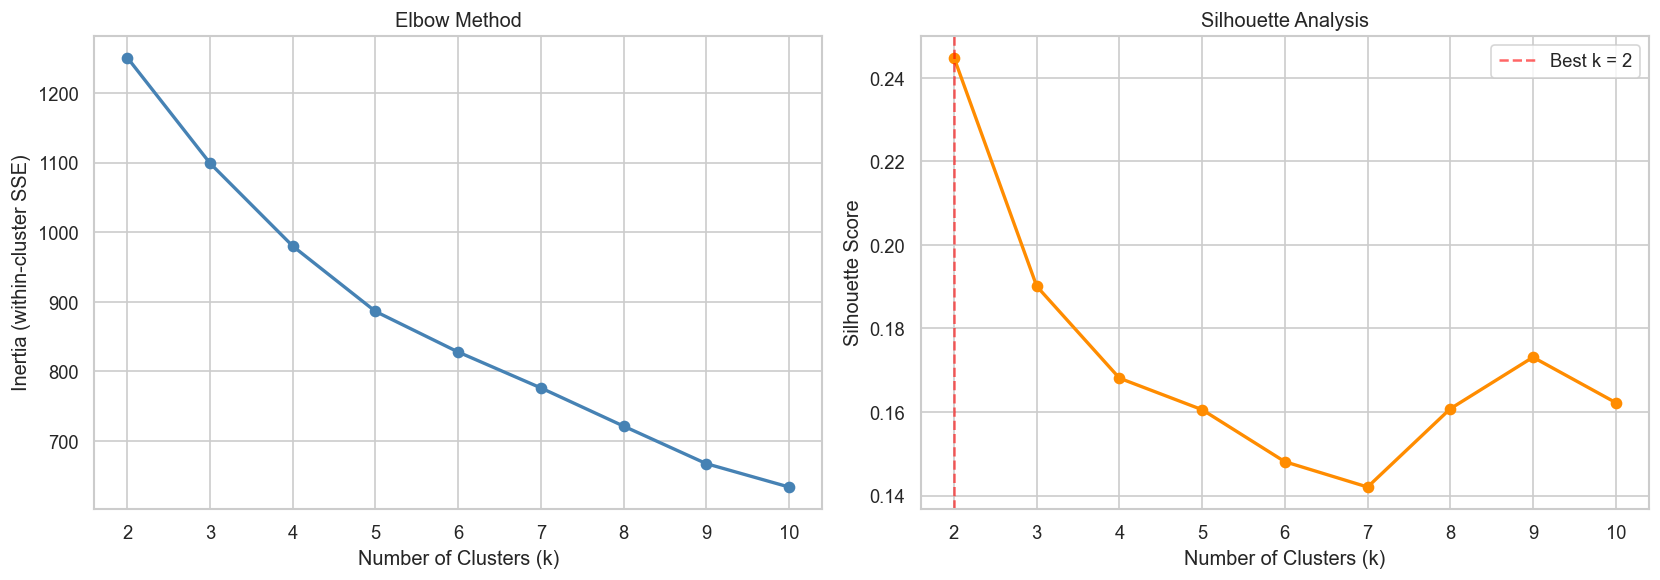


Best silhouette at k = 2 (0.2448)


In [4]:
# Elbow method + Silhouette score
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42, max_iter=500)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels)
    silhouettes.append(sil)
    print(f'  k={k:2d}  inertia={km.inertia_:8.1f}  silhouette={sil:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, silhouettes, 'o-', color='darkorange', lw=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xticks(list(K_range))

best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='red', ls='--', alpha=0.6,
                label=f'Best k = {best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nBest silhouette at k = {best_k} ({max(silhouettes):.4f})')

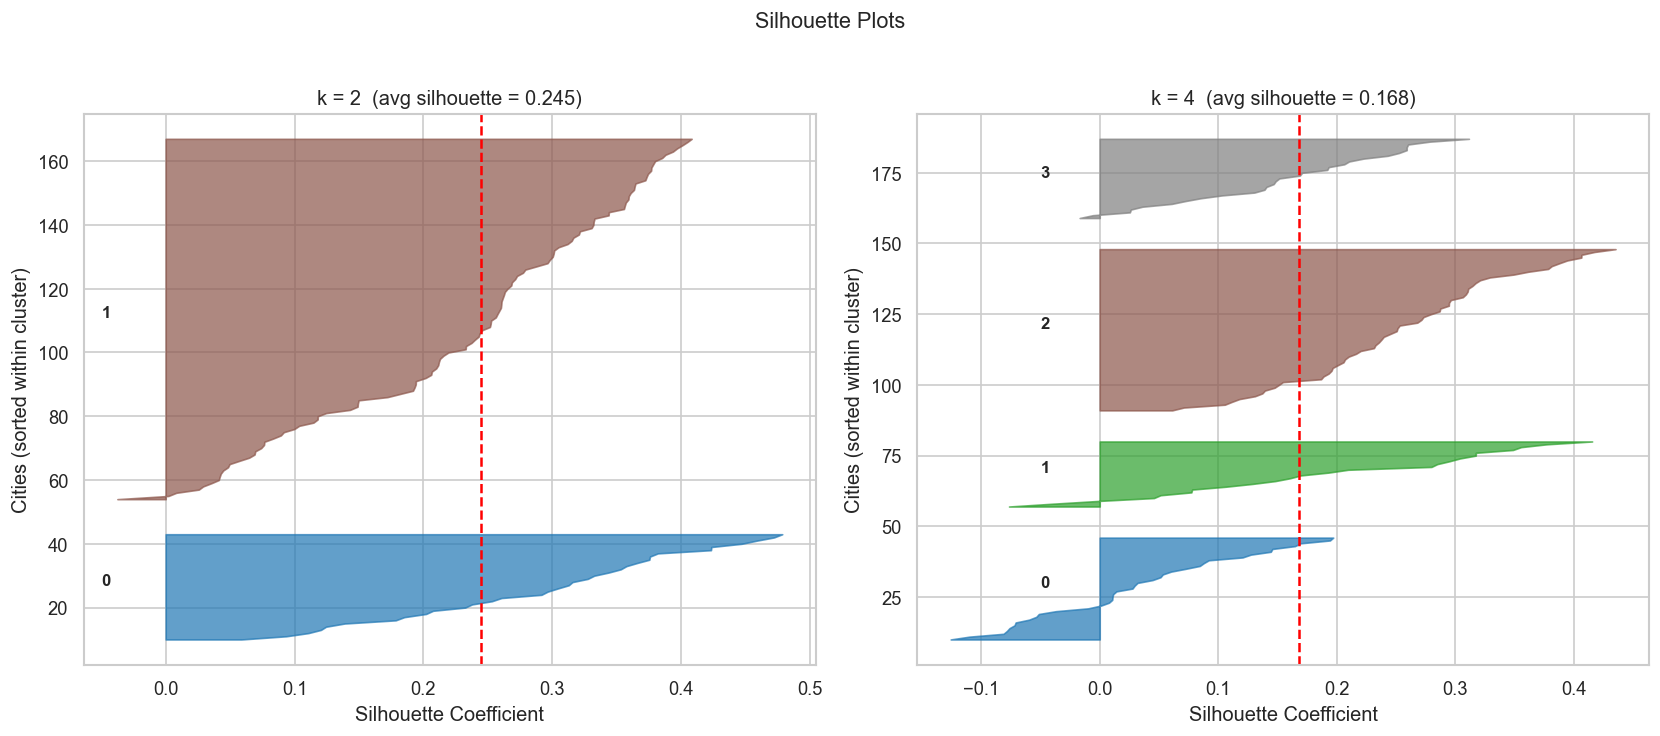

In [5]:
# Silhouette plot for the chosen k
# We test both the silhouette-optimal k and k=4 (theory-driven: 4 roles)
test_ks = sorted(set([best_k, 4]))

fig, axes = plt.subplots(1, len(test_ks), figsize=(7 * len(test_ks), 6))
if len(test_ks) == 1:
    axes = [axes]

for ax, k in zip(axes, test_ks):
    km = KMeans(n_clusters=k, n_init=20, random_state=42, max_iter=500)
    labels = km.fit_predict(X)
    sil_vals = silhouette_samples(X, labels)
    avg_sil = silhouette_score(X, labels)

    y_lower = 10
    for i in range(k):
        cluster_sil = np.sort(sil_vals[labels == i])
        size = cluster_sil.shape[0]
        y_upper = y_lower + size
        color = plt.cm.tab10(i / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10, fontweight='bold')
        y_lower = y_upper + 10

    ax.axvline(avg_sil, color='red', ls='--', lw=1.5)
    ax.set_title(f'k = {k}  (avg silhouette = {avg_sil:.3f})', fontsize=12)
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cities (sorted within cluster)')

plt.suptitle('Silhouette Plots', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9.3 – Final Clustering (k = 4)

We use **k = 4** as our primary model, matching the four theoretically motivated roles:
originators, collaboration hubs, bridge cities, and peripheral / late adopters.
If the silhouette-optimal k differs, we compare both.

In [6]:
CHOSEN_K = 4

km_final = KMeans(n_clusters=CHOSEN_K, n_init=30, random_state=42, max_iter=500)
labels = km_final.fit_predict(X)

df['cluster'] = np.nan
df.loc[X_raw.index, 'cluster'] = labels

print(f'Cluster sizes (k = {CHOSEN_K}):')
print(df['cluster'].value_counts().sort_index().to_string())
print(f'\nSilhouette score: {silhouette_score(X, labels):.4f}')

Cluster sizes (k = 4):
cluster
0.0    52
1.0    33
2.0    25
3.0    38

Silhouette score: 0.1598


In [7]:
raw_cols = [
    'origination_count', 'adoption_count', 'weighted_degree',
    'betweenness', 'origination_rate_pop', 'adoption_rate_pop',
]
profiles = df.groupby('cluster')[raw_cols].mean().round(2)

for feat, label in zip(cluster_features, FEAT_LABELS):
    profiles[label] = df.groupby('cluster')[feat].mean().round(3)

profiles['n_cities'] = df.groupby('cluster').size()

print('Cluster Profiles (mean values):')
display(profiles.T)

Cluster Profiles (mean values):


cluster,0.0,1.0,2.0,3.0
origination_count,14.460,9.360,294.080,2.420
adoption_count,187.620,133.060,945.320,36.260
weighted_degree,2291.850,1605.390,5988.120,445.660
betweenness,0.000,0.000,0.000,0.020
origination_rate_pop,11.620,1.910,304.010,2.740
adoption_rate_pop,143.190,19.810,776.460,38.770
Origination,2.392,1.817,5.119,0.996
Adoption,5.061,4.609,6.498,3.438
Betweenness,0.729,1.265,0.298,2.777
Orig rate (pop),1.732,0.660,3.941,0.926


In [8]:
cluster_order = profiles.sort_values('origination_count', ascending=False).index.tolist()

ROLE_LABELS = {}
remaining = list(cluster_order)

ROLE_LABELS[remaining.pop(0)] = 'Global Innovation Hub'

bridge_candidates = remaining.copy()
bridge_id = max(bridge_candidates, key=lambda c: profiles.loc[c, 'Cross-region']
                if 'Cross-region' in profiles.columns
                else df.loc[df['cluster']==c, 'cross_region_ratio_calc'].mean())
ROLE_LABELS[bridge_id] = 'Global Bridge'
remaining.remove(bridge_id)

if len(remaining) >= 2:
    active_id = max(remaining, key=lambda c: profiles.loc[c, 'adoption_count'])
    ROLE_LABELS[active_id] = 'Active Collaborator'
    remaining.remove(active_id)

for c in remaining:
    ROLE_LABELS[c] = 'Peripheral Contributor'

df['role'] = df['cluster'].map(ROLE_LABELS)

role_map = ROLE_LABELS
role_names_ordered = ['Global Innovation Hub', 'Global Bridge', 'Active Collaborator', 'Peripheral Contributor']

print('Role assignments:')
for cid, role in sorted(ROLE_LABELS.items()):
    n = (df['cluster'] == cid).sum()
    mean_orig = df.loc[df['cluster'] == cid, 'origination_count'].mean()
    mean_adopt = df.loc[df['cluster'] == cid, 'adoption_count'].mean()
    mean_deg = df.loc[df['cluster'] == cid, 'weighted_degree'].mean()
    print(f'  Cluster {cid} → {role:30s}  (n={n:3d}, '
          f'orig={mean_orig:.0f}, adopt={mean_adopt:.0f}, degree={mean_deg:.0f})')

Role assignments:
  Cluster 0.0 → Active Collaborator             (n= 52, orig=14, adopt=188, degree=2292)
  Cluster 1.0 → Global Bridge                   (n= 33, orig=9, adopt=133, degree=1605)
  Cluster 2.0 → Global Innovation Hub           (n= 25, orig=294, adopt=945, degree=5988)
  Cluster 3.0 → Peripheral Contributor          (n= 38, orig=2, adopt=36, degree=446)


## 9.4 – Cluster Visualisation

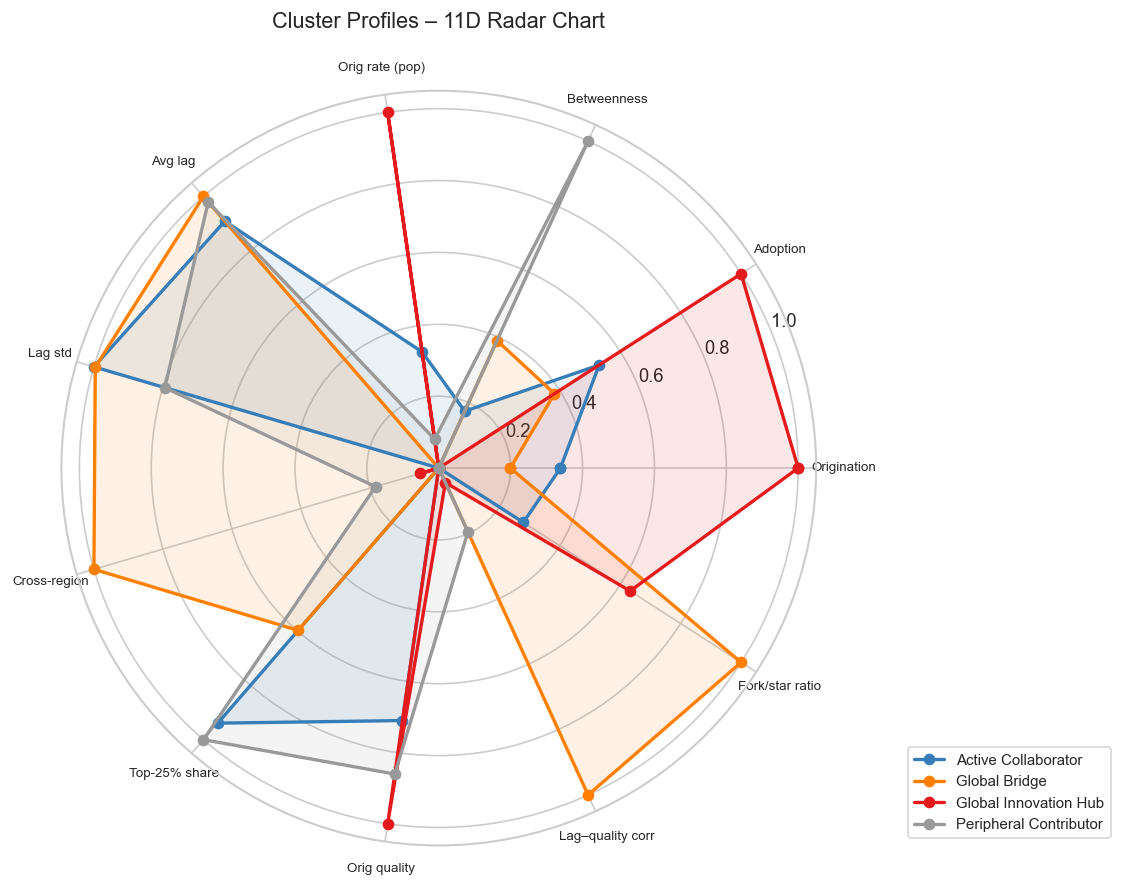

In [9]:
radar_cols = cluster_features
radar_labels = FEAT_LABELS

centroids_std = pd.DataFrame(km_final.cluster_centers_, columns=cluster_features)
centroids_norm = (centroids_std - centroids_std.min()) / (centroids_std.max() - centroids_std.min() + 1e-9)

n_vars = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

role_colors = {
    'Global Innovation Hub': '#e41a1c',
    'Global Bridge': '#ff7f00',
    'Active Collaborator': '#377eb8',
    'Peripheral Contributor': '#999999',
}

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for cid in range(CHOSEN_K):
    role = role_map[cid]
    vals = centroids_norm.iloc[cid][radar_cols].tolist()
    vals += vals[:1]
    color = role_colors.get(role, 'grey')
    ax.plot(angles, vals, 'o-', lw=2, label=role, color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=8)
ax.set_title('Cluster Profiles – 11D Radar Chart', fontsize=13, pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.4, 0), fontsize=9)
plt.tight_layout()
plt.show()

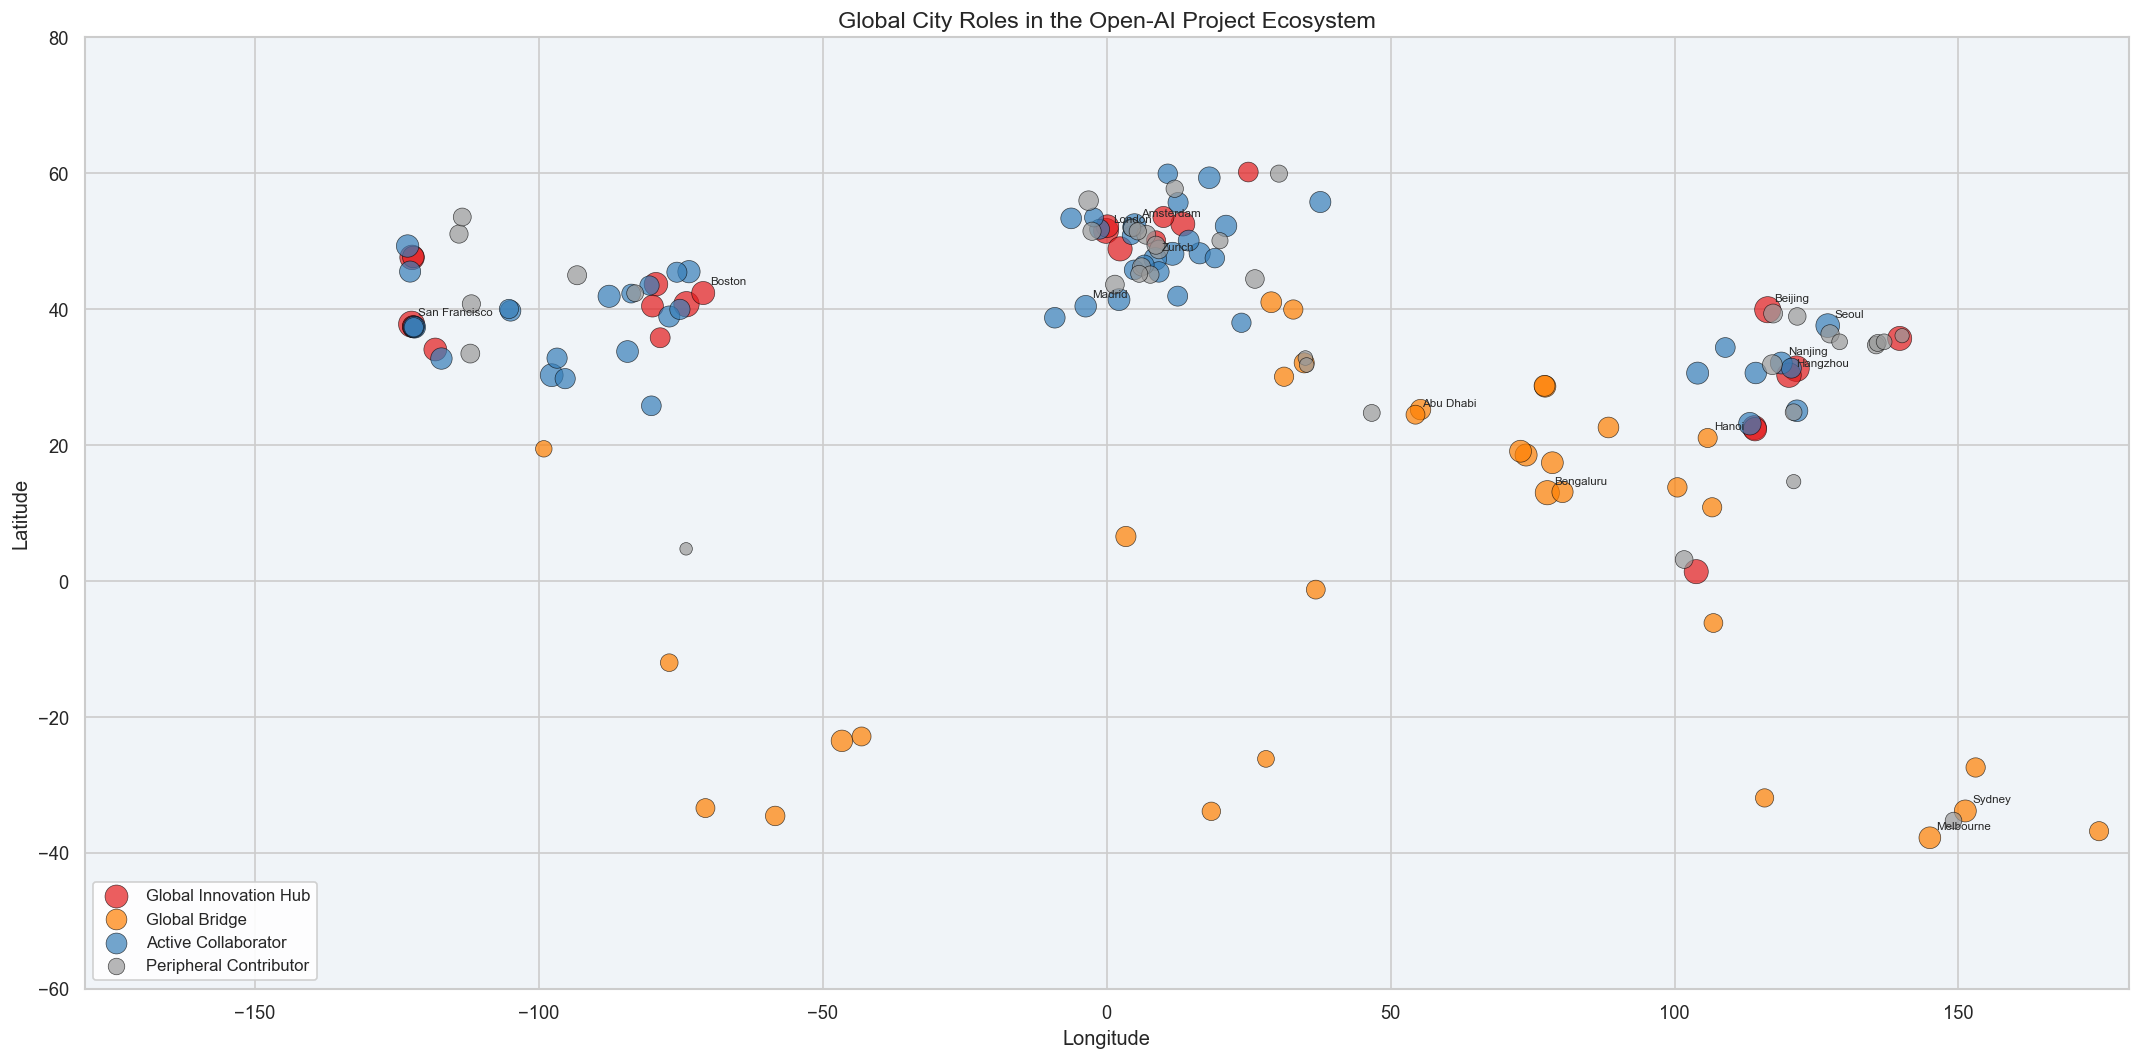

In [10]:
# Global map: cities coloured by cluster role
fig, ax = plt.subplots(figsize=(18, 9))
ax.set_facecolor('#f0f4f8')
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)

# Bubble size ~ log(entity_count)
sizes = np.log1p(df['entity_count']) * 30 + 15

for role in role_names_ordered:
    mask = df['role'] == role
    color = role_colors.get(role, 'grey')
    ax.scatter(df.loc[mask, 'lon'], df.loc[mask, 'lat'],
               s=sizes[mask], c=color, alpha=0.7,
               edgecolors='black', linewidths=0.4, label=role, zorder=3)

# Label top cities per cluster
for role in role_names_ordered[:3]:  # label top roles
    subset = df[df['role'] == role].nlargest(5, 'origination_count')
    for _, row in subset.iterrows():
        ax.annotate(row['city'], (row['lon'], row['lat']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Global City Roles in the Open-AI Project Ecosystem', fontsize=14)
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

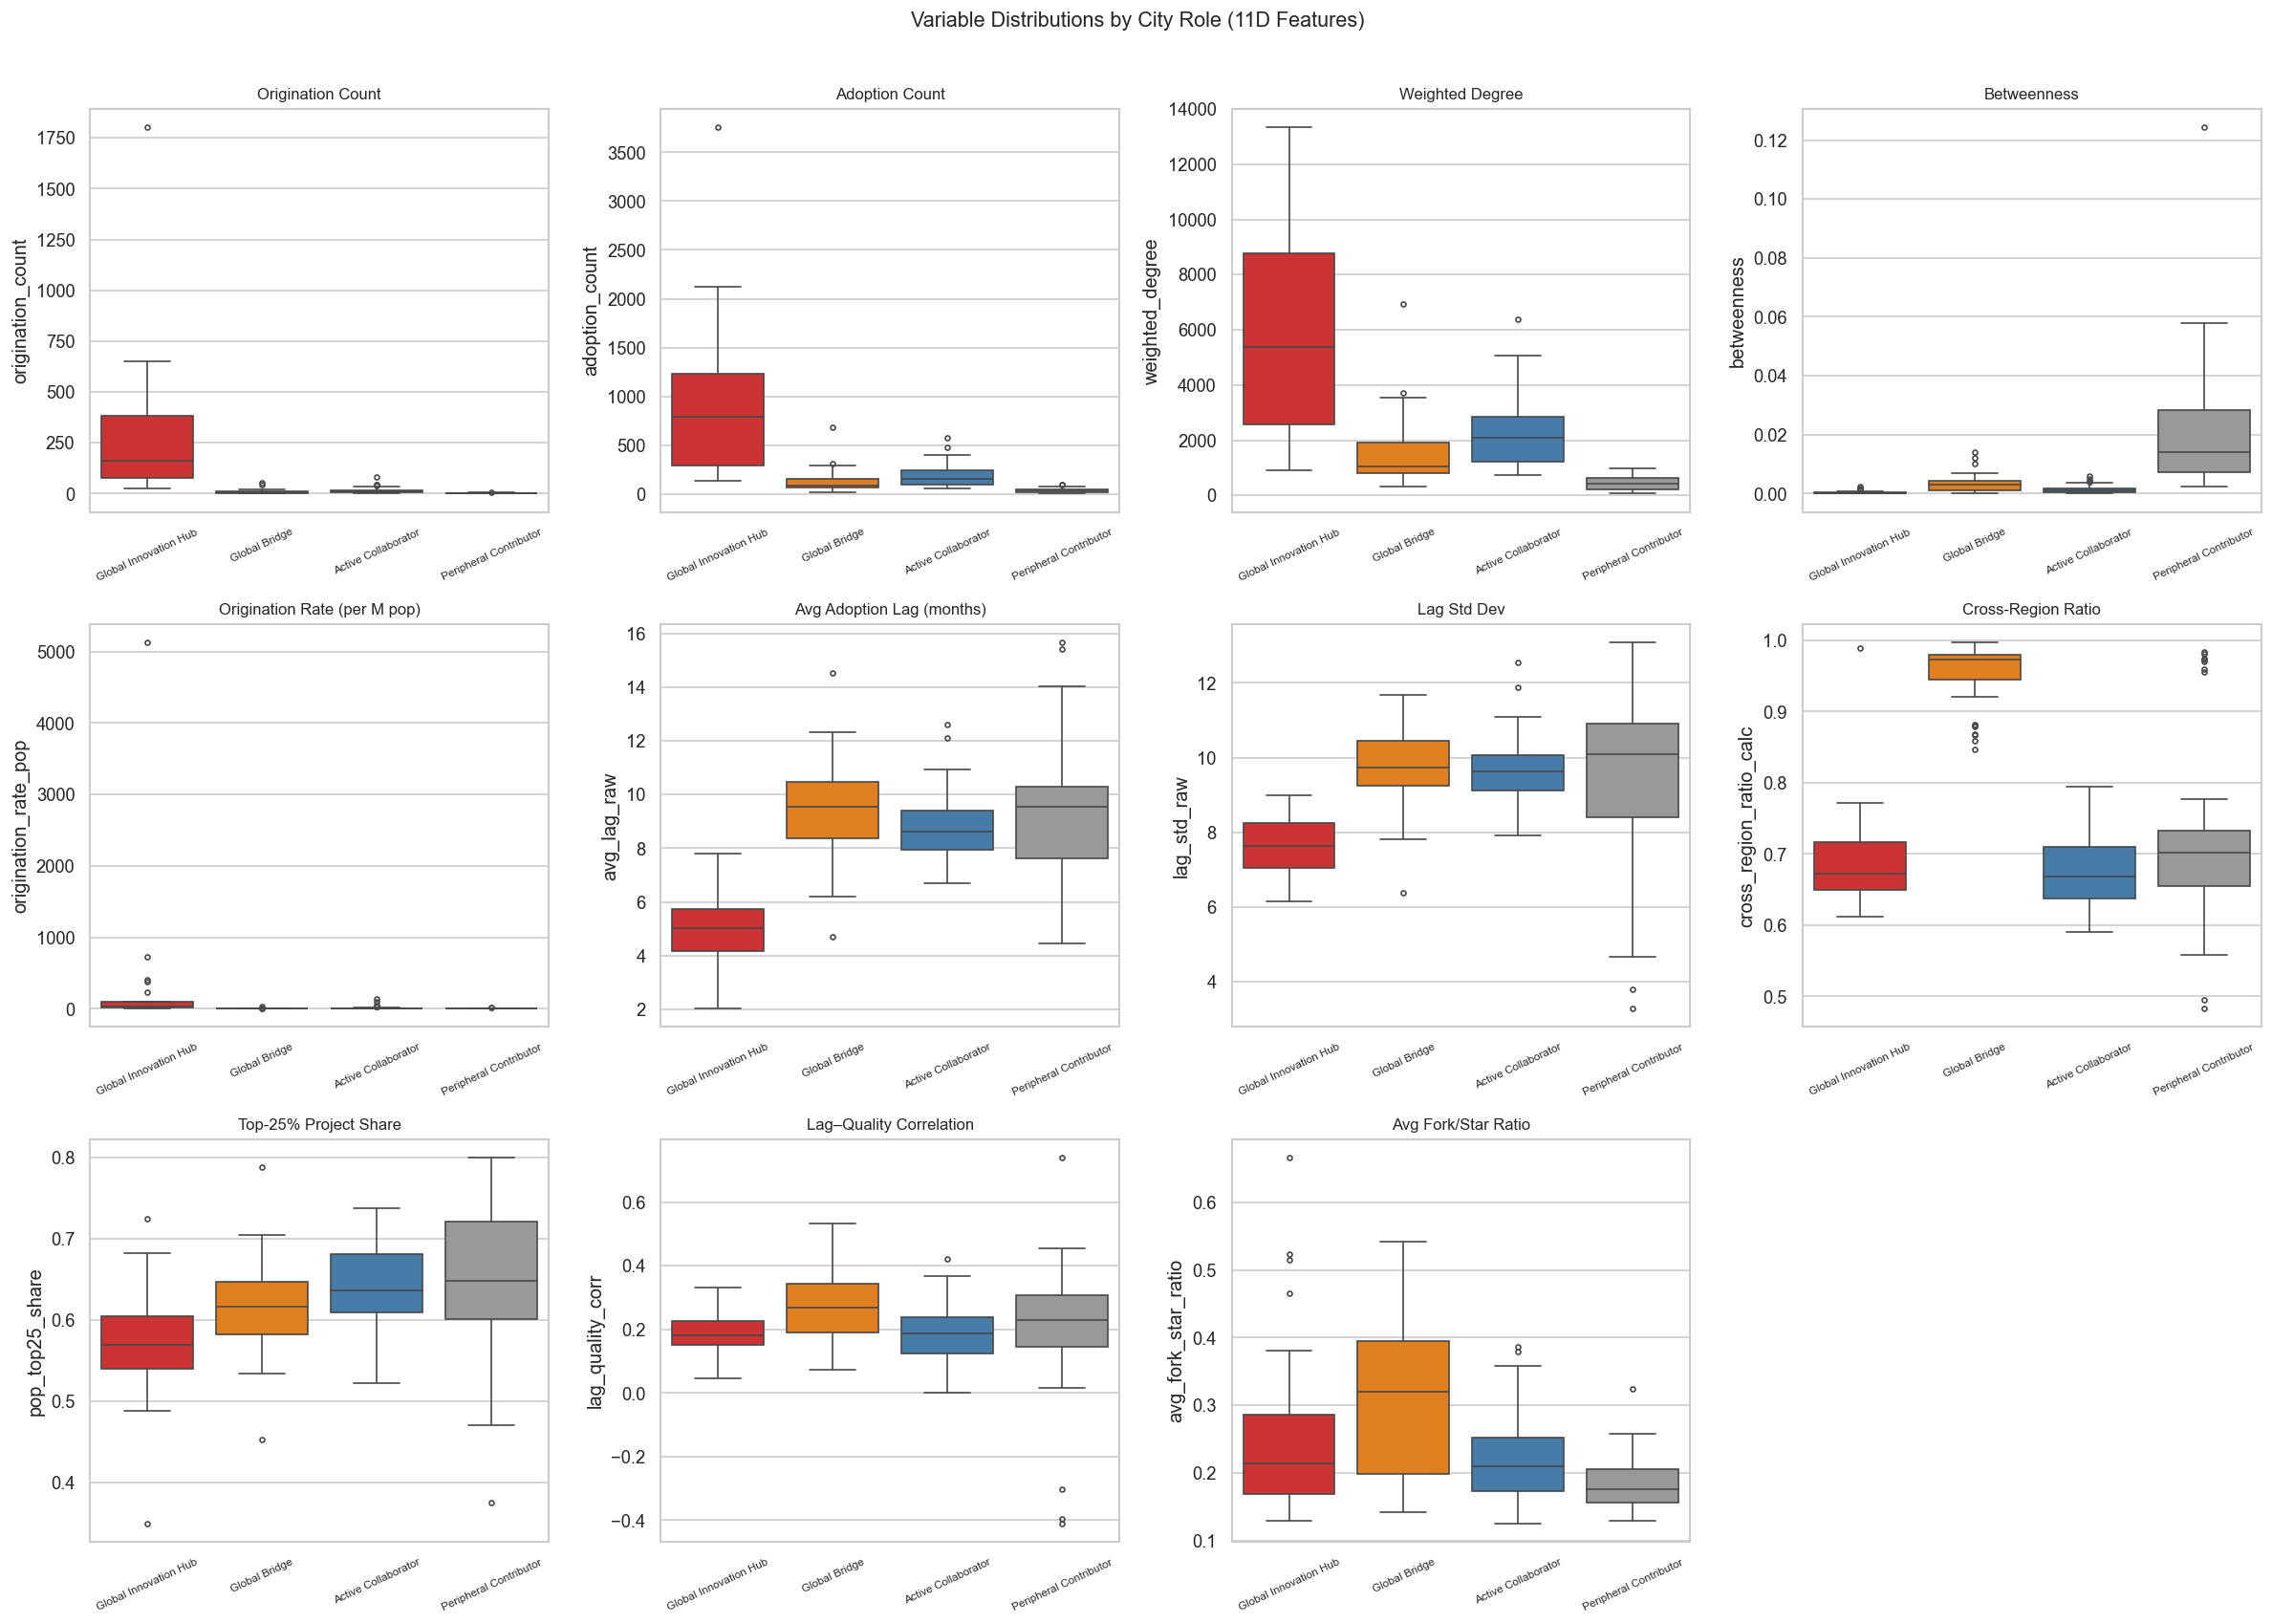

In [11]:
box_vars = [
    ('origination_count', 'Origination Count'),
    ('adoption_count', 'Adoption Count'),
    ('weighted_degree', 'Weighted Degree'),
    ('betweenness', 'Betweenness'),
    ('origination_rate_pop', 'Origination Rate (per M pop)'),
    ('avg_lag_raw', 'Avg Adoption Lag (months)'),
    ('lag_std_raw', 'Lag Std Dev'),
    ('cross_region_ratio_calc', 'Cross-Region Ratio'),
    ('pop_top25_share', 'Top-25% Project Share'),
    ('lag_quality_corr', 'Lag–Quality Correlation'),
    ('avg_fork_star_ratio', 'Avg Fork/Star Ratio'),
]

n_rows = 3
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 14))
for i, (col, title) in enumerate(box_vars):
    ax = axes.flatten()[i]
    order = role_names_ordered
    palette = [role_colors[r] for r in order]
    sns.boxplot(data=df, x='role', y=col, order=order, palette=palette,
                ax=ax, fliersize=3)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=25, labelsize=7)
    ax.set_xlabel('')

for j in range(len(box_vars), n_rows * n_cols):
    axes.flatten()[j].set_visible(False)

plt.suptitle('Variable Distributions by City Role (11D Features)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

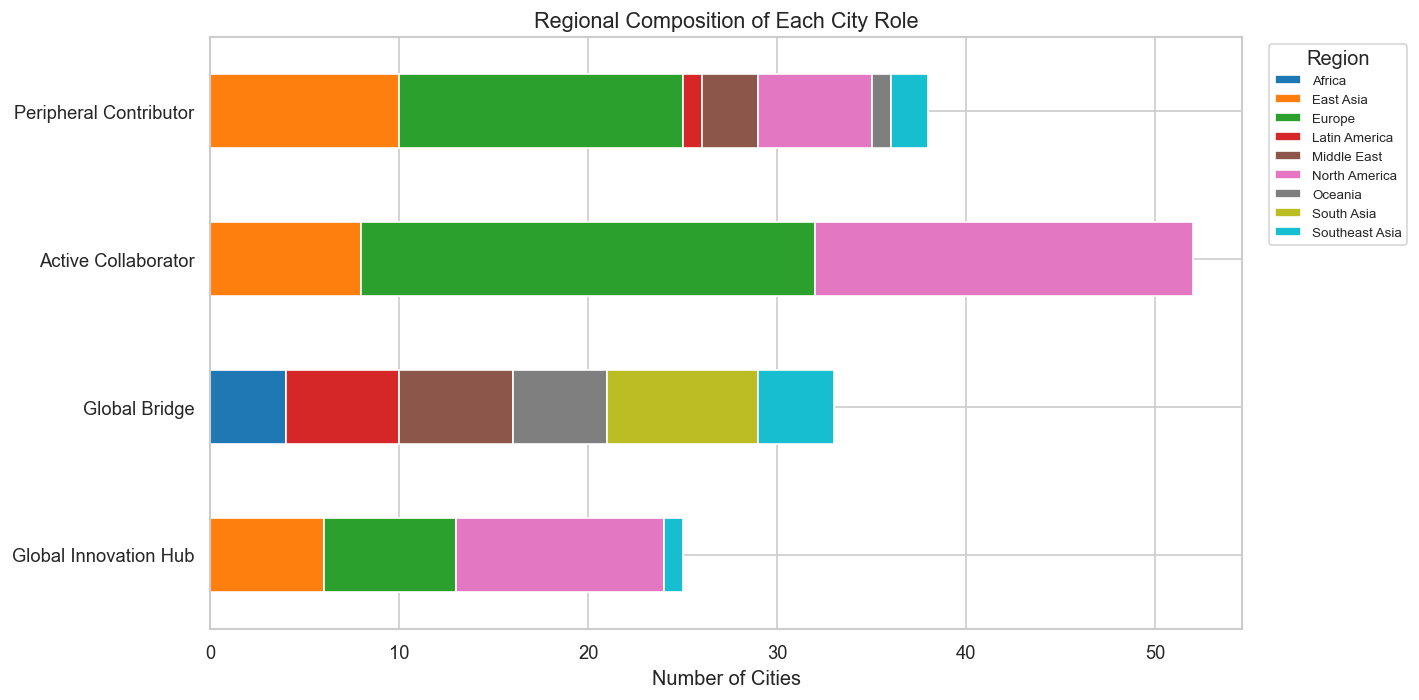

Regional composition:


region,Africa,East Asia,Europe,Latin America,Middle East,North America,Oceania,South Asia,Southeast Asia
role,,,,,,,,,
Global Innovation Hub,0,6,7,0,0,11,0,0,1
Global Bridge,4,0,0,6,6,0,5,8,4
Active Collaborator,0,8,24,0,0,20,0,0,0
Peripheral Contributor,0,10,15,1,3,6,1,0,2


In [12]:
# Regional composition of each cluster
role_region = pd.crosstab(df['role'], df['region'])
role_region = role_region.loc[role_names_ordered]

fig, ax = plt.subplots(figsize=(12, 6))
role_region.plot.barh(stacked=True, ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Regional Composition of Each City Role', fontsize=13)
ax.set_xlabel('Number of Cities')
ax.set_ylabel('')
ax.legend(title='Region', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

print('Regional composition:')
display(role_region)

In [13]:
# List representative cities in each cluster
print('=' * 70)
print('REPRESENTATIVE CITIES BY ROLE')
print('=' * 70)

for role in role_names_ordered:
    subset = df[df['role'] == role].sort_values('origination_count', ascending=False)
    n = len(subset)
    top_cities = subset.head(min(10, n))

    print(f'\n▸ {role} ({n} cities)')
    for _, row in top_cities.iterrows():
        print(f'    {row["city"]:20s} ({row["country"]:15s})  '
              f'orig={row["origination_count"]:5.0f}  '
              f'adopt={row["adoption_count"]:6.0f}  '
              f'degree={row["weighted_degree"]:7.0f}')

REPRESENTATIVE CITIES BY ROLE

▸ Global Innovation Hub (25 cities)
    San Francisco        (United States  )  orig= 1802  adopt=  3757  degree=  13337
    Beijing              (China          )  orig=  653  adopt=  2126  degree=  10471
    London               (United Kingdom )  orig=  633  adopt=  1784  degree=  10389
    Hangzhou             (China          )  orig=  533  adopt=  1233  degree=   6463
    Boston               (United States  )  orig=  513  adopt=   910  degree=   5051
    New York             (United States  )  orig=  496  adopt=  1594  degree=  11214
    Seattle              (United States  )  orig=  382  adopt=  1226  degree=   8762
    Redmond              (United States  )  orig=  359  adopt=   478  degree=   2357
    Paris                (France         )  orig=  288  adopt=   934  degree=   7000
    Shanghai             (China          )  orig=  269  adopt=  1416  degree=   9198

▸ Global Bridge (33 cities)
    Bengaluru            (India          )  orig=   52

## 9.5 – Save Results

In [14]:
save_df = df[['city', 'cluster', 'role']].copy()
city_out = city_attr.drop(columns=['cluster', 'role'], errors='ignore')
city_out = city_out.merge(save_df, on='city', how='left')
city_out.to_csv(DATA / 'city_attributes.csv', index=False)
print(f'✅ Saved cluster & role columns to city_attributes.csv ({len(city_out)} rows)')

print(f'\n📊 Final cluster summary:')
summary = df.groupby('role').agg(
    n_cities=('city', 'count'),
    mean_origination=('origination_count', 'mean'),
    mean_adoption=('adoption_count', 'mean'),
    mean_degree=('weighted_degree', 'mean'),
    mean_betweenness=('betweenness', 'mean'),
    mean_cross_region=('cross_region_ratio_calc', 'mean'),
    top_city=('origination_count', lambda x: df.loc[x.idxmax(), 'city']),
).round(2)
display(summary)

✅ Saved cluster & role columns to city_attributes.csv (148 rows)

📊 Final cluster summary:


,n_cities,mean_origination,mean_adoption,mean_degree,mean_betweenness,mean_cross_region,top_city
role,,,,,,,
Active Collaborator,52,14.46,187.62,2291.85,0.00,0.68,Seoul
Global Bridge,33,9.36,133.06,1605.39,0.00,0.95,Bengaluru
Global Innovation Hub,25,294.08,945.32,5988.12,0.00,0.69,San Francisco
Peripheral Contributor,38,2.42,36.26,445.66,0.02,0.73,Daejeon


---

## 9.6 – K-Means Parameter Sensitivity Analysis

Compare **k = 3, 4, 5** with increased `n_init = 50` for more stable centroid initialisation.
We evaluate each configuration on silhouette score, Calinski–Harabasz index, and Davies–Bouldin index.

In [15]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

N_INIT_HIGH = 50
test_k_values = [3, 4, 5]

kmeans_results = {}

for k in test_k_values:
    km = KMeans(n_clusters=k, n_init=N_INIT_HIGH, random_state=42, max_iter=500)
    labs = km.fit_predict(X)

    sil = silhouette_score(X, labs)
    ch  = calinski_harabasz_score(X, labs)
    db  = davies_bouldin_score(X, labs)

    kmeans_results[k] = {
        'model': km,
        'labels': labs,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db,
        'inertia': km.inertia_,
    }

    print(f'k={k}  |  Silhouette={sil:.4f}  |  CH={ch:.1f}  |  DB={db:.3f}  |  Inertia={km.inertia_:.1f}')

comp_df = pd.DataFrame({
    k: {m: v for m, v in vals.items() if m not in ('model', 'labels')}
    for k, vals in kmeans_results.items()
}).T
comp_df.index.name = 'k'
print('\n── K-Means Comparison Table (n_init=50) ──')
display(comp_df.round(4))

k=3  |  Silhouette=0.1905  |  CH=34.9  |  DB=1.865  |  Inertia=1099.0
k=4  |  Silhouette=0.1598  |  CH=31.8  |  DB=1.721  |  Inertia=979.5
k=5  |  Silhouette=0.1605  |  CH=29.9  |  DB=1.613  |  Inertia=886.2

── K-Means Comparison Table (n_init=50) ──


,silhouette,calinski_harabasz,davies_bouldin,inertia
k,,,,
3,0.1905,34.9018,1.8650,1098.9569
4,0.1598,31.7795,1.7213,979.5003
5,0.1605,29.9248,1.6132,886.2000


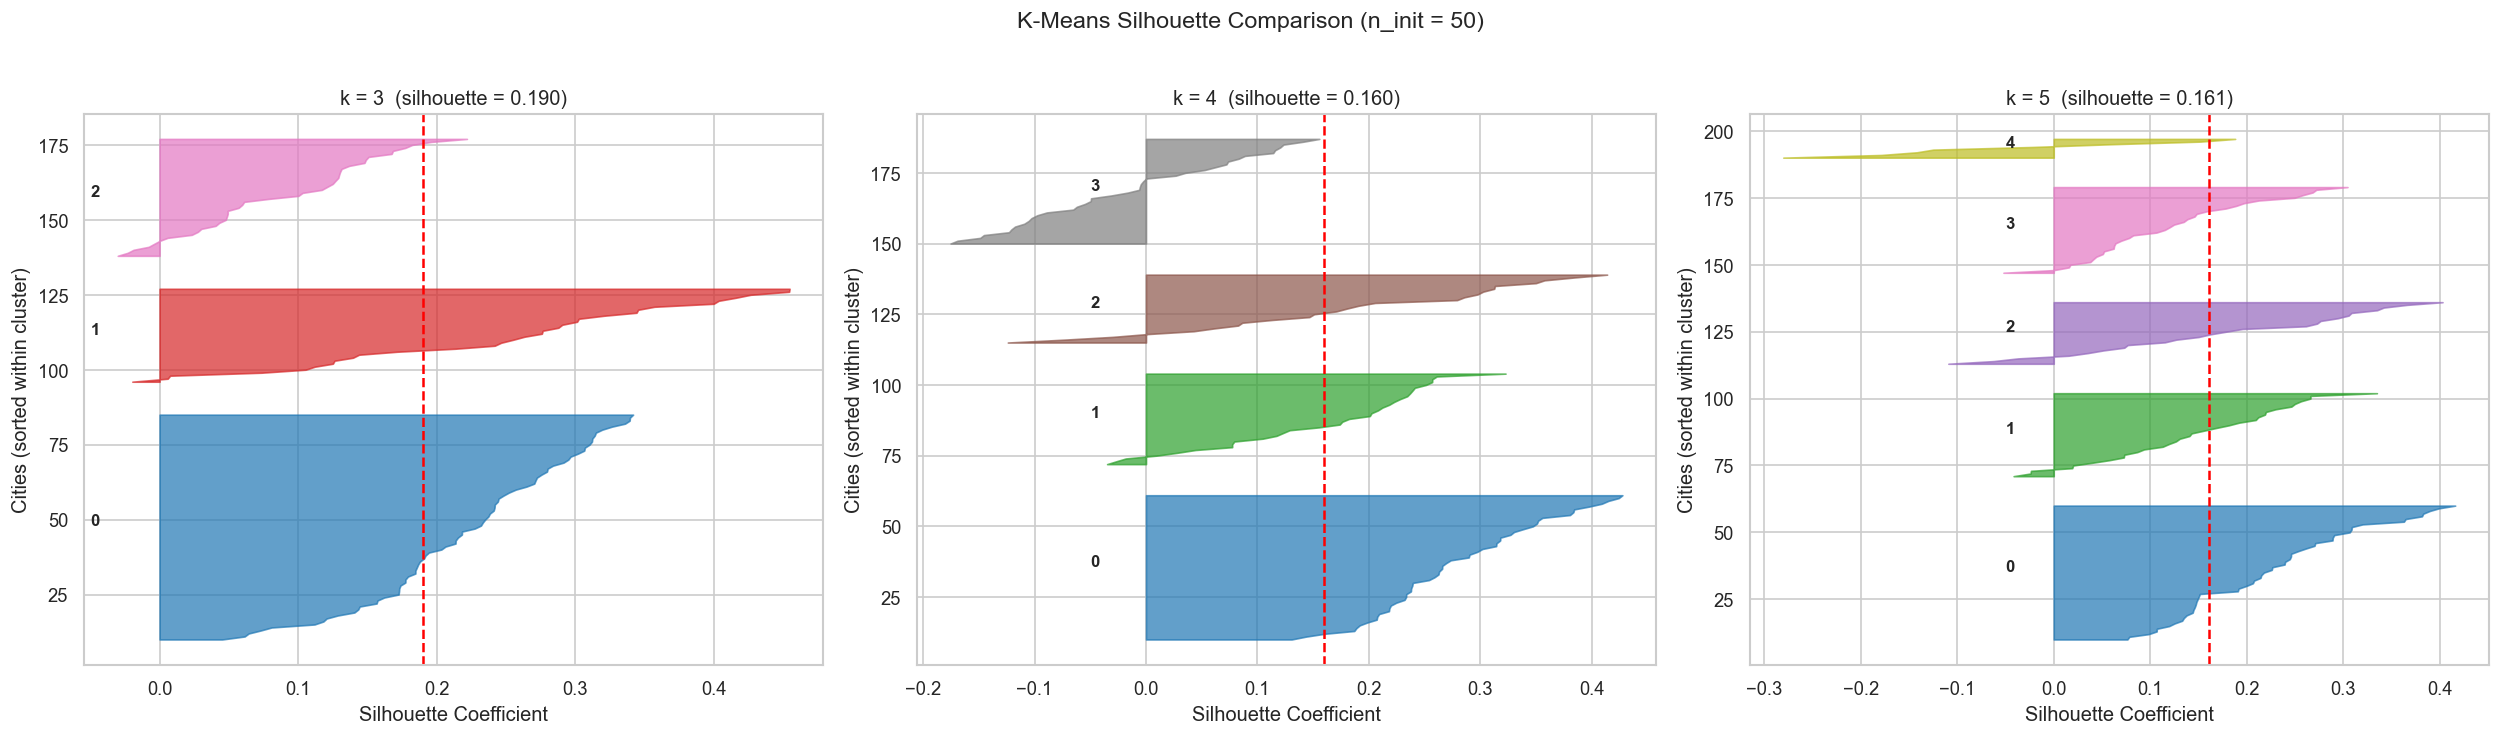

In [16]:
# Silhouette plots side-by-side for k = 3, 4, 5
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, k in zip(axes, test_k_values):
    labs = kmeans_results[k]['labels']
    sil_vals = silhouette_samples(X, labs)
    avg_sil = kmeans_results[k]['silhouette']

    y_lower = 10
    for i in range(k):
        cluster_sil = np.sort(sil_vals[labs == i])
        size = cluster_sil.shape[0]
        y_upper = y_lower + size
        color = plt.cm.tab10(i / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10, fontweight='bold')
        y_lower = y_upper + 10

    ax.axvline(avg_sil, color='red', ls='--', lw=1.5)
    ax.set_title(f'k = {k}  (silhouette = {avg_sil:.3f})', fontsize=12)
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cities (sorted within cluster)')

plt.suptitle('K-Means Silhouette Comparison (n_init = 50)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

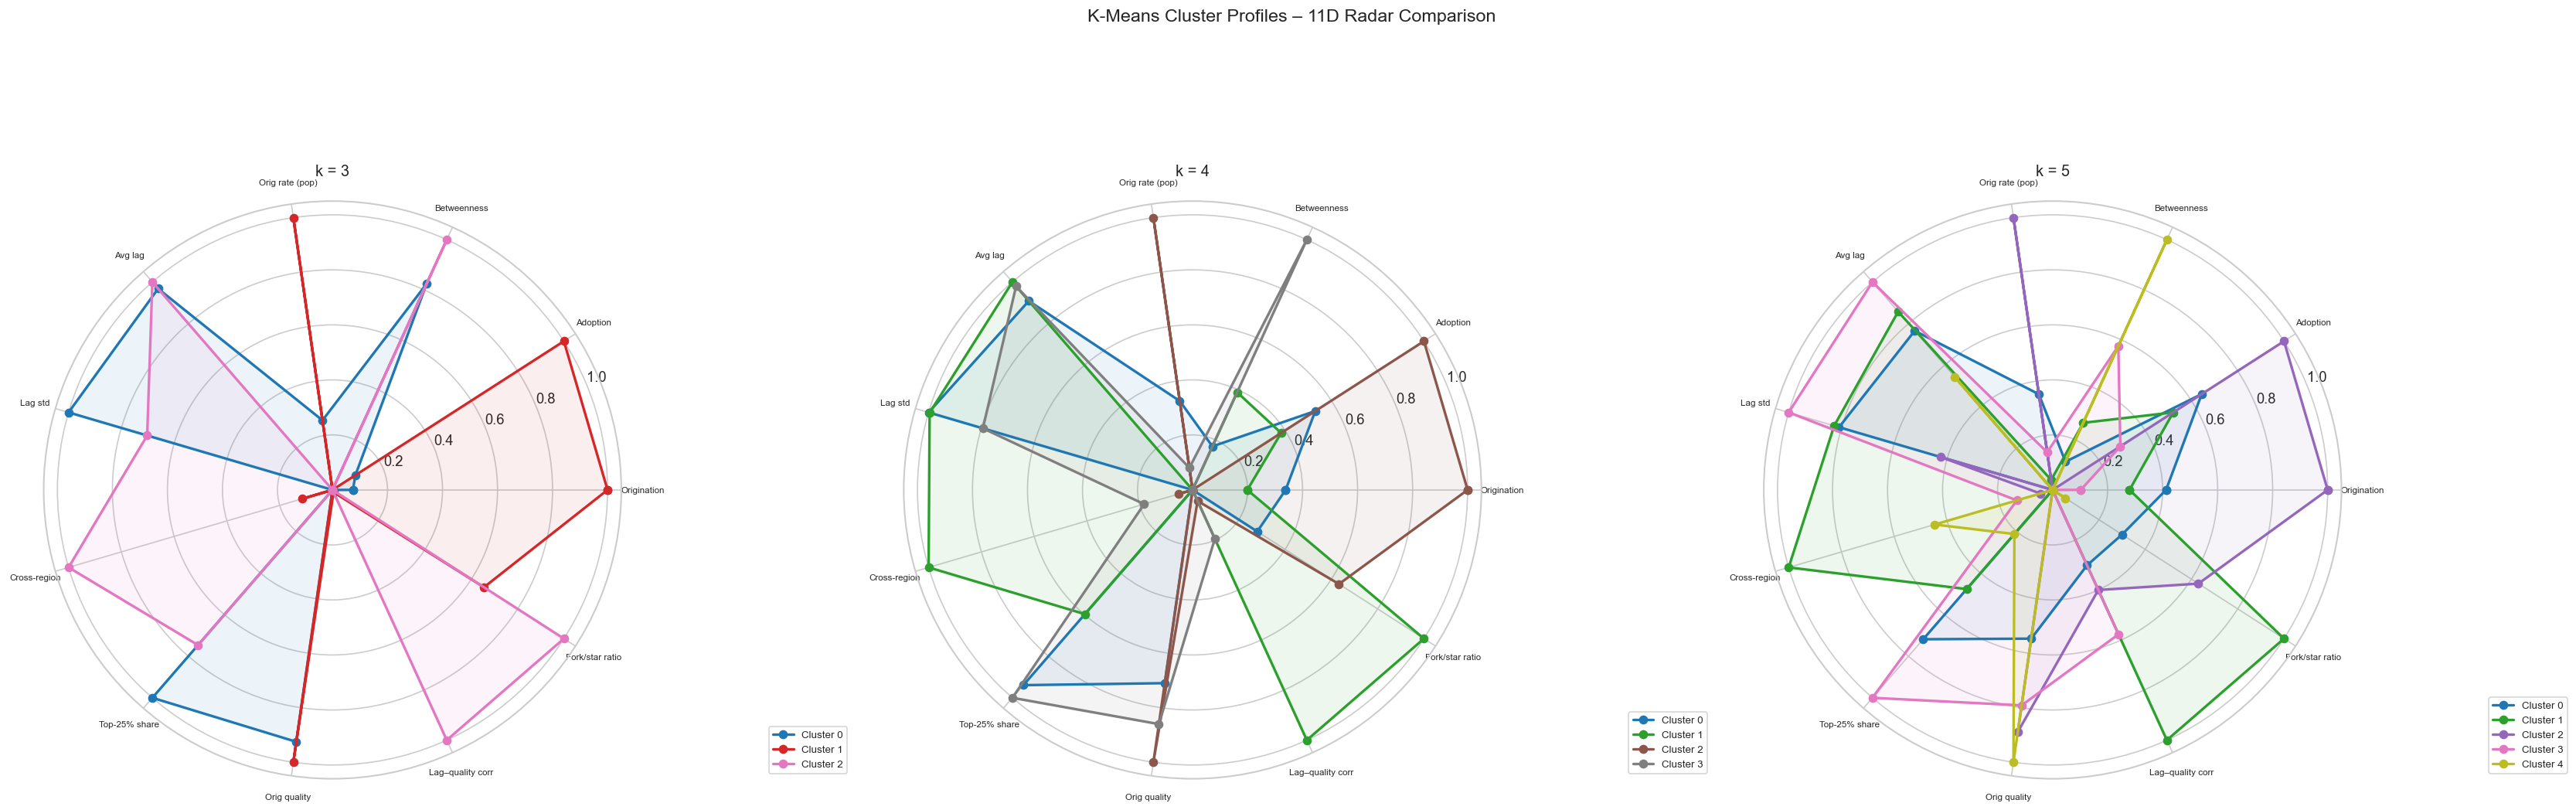

In [17]:
# Radar charts for k=3, 4, 5 side-by-side (11D)
fig, axes = plt.subplots(1, 3, figsize=(28, 9), subplot_kw=dict(polar=True))

radar_cols_sens = cluster_features
radar_labels_sens = FEAT_LABELS
n_vars = len(radar_cols_sens)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

for ax, k in zip(axes, test_k_values):
    centroids_std = pd.DataFrame(
        kmeans_results[k]['model'].cluster_centers_, columns=cluster_features)
    centroids_norm = (centroids_std - centroids_std.min()) / (
        centroids_std.max() - centroids_std.min() + 1e-9)

    for cid in range(k):
        vals = centroids_norm.iloc[cid][radar_cols_sens].tolist()
        vals += vals[:1]
        color = plt.cm.tab10(cid / k)
        ax.plot(angles, vals, 'o-', lw=2, label=f'Cluster {cid}', color=color)
        ax.fill(angles, vals, alpha=0.08, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels_sens, fontsize=7)
    ax.set_title(f'k = {k}', fontsize=12, pad=20)
    ax.legend(loc='lower right', bbox_to_anchor=(1.4, 0), fontsize=8)

plt.suptitle('K-Means Cluster Profiles – 11D Radar Comparison', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

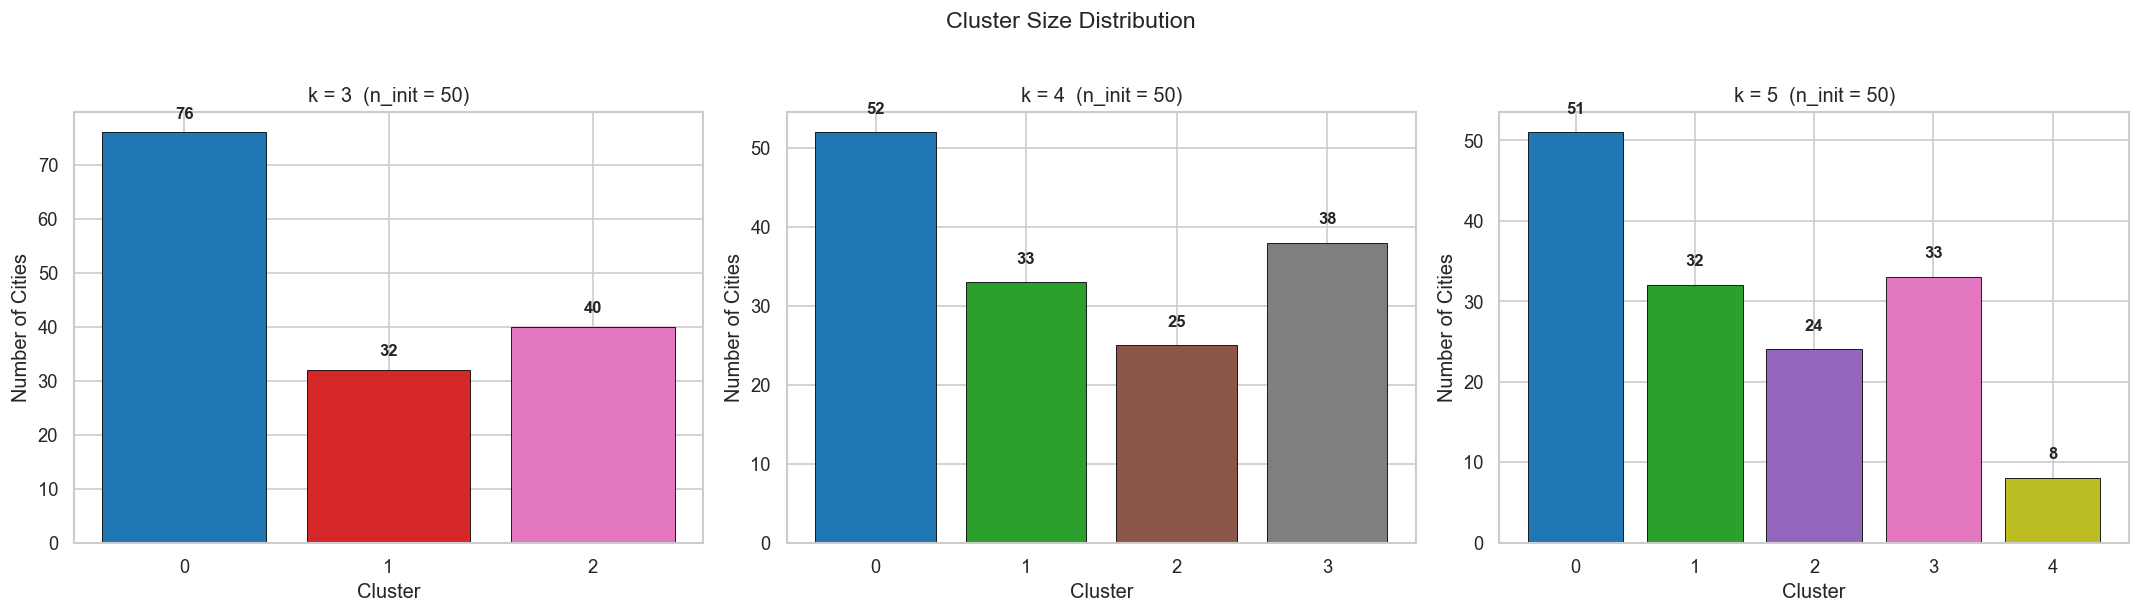

In [18]:
# Cluster size distribution for k = 3, 4, 5
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, k in zip(axes, test_k_values):
    labs = kmeans_results[k]['labels']
    sizes = pd.Series(labs).value_counts().sort_index()
    colors = [plt.cm.tab10(i / k) for i in sizes.index]
    bars = ax.bar(sizes.index, sizes.values, color=colors, edgecolor='black', lw=0.5)
    for bar, val in zip(bars, sizes.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Number of Cities')
    ax.set_title(f'k = {k}  (n_init = {N_INIT_HIGH})', fontsize=12)
    ax.set_xticks(range(k))

plt.suptitle('Cluster Size Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 9.7 – DBSCAN: Density-Based Clustering

DBSCAN does **not** require a pre-set number of clusters. It discovers arbitrarily shaped clusters
and labels low-density points as noise (−1). We tune `eps` using the **k-distance graph** method
and evaluate several `min_samples` values.

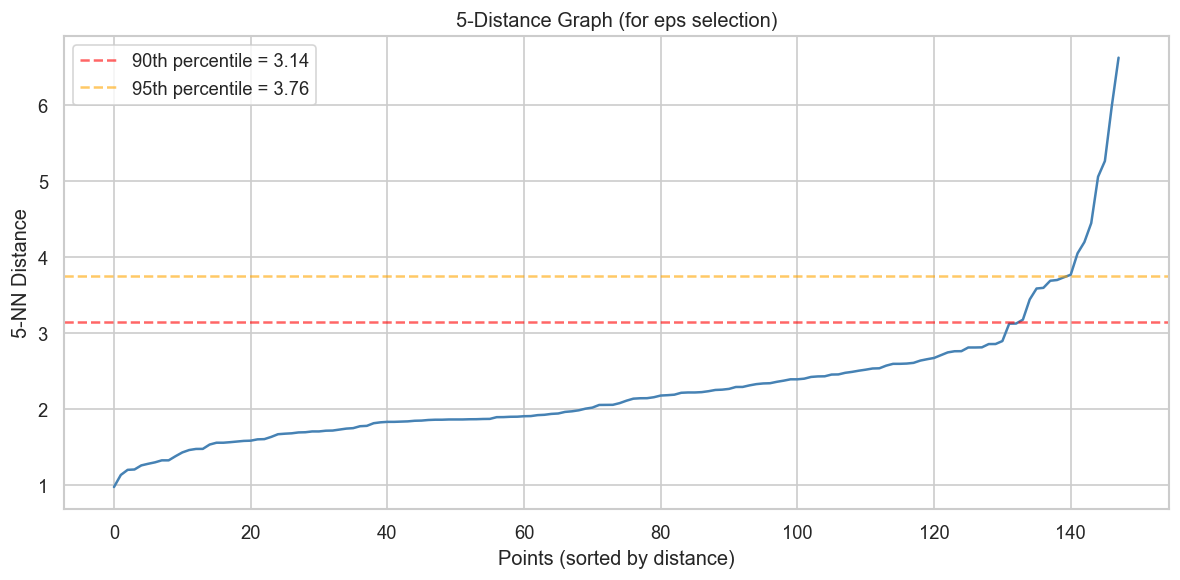

Distance percentiles:
  P50 = 2.068
  P75 = 2.523
  P85 = 2.809
  P90 = 3.141
  P95 = 3.757


In [19]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# k-distance graph to guide eps selection
k_nn = 5
nn = NearestNeighbors(n_neighbors=k_nn)
nn.fit(X)
distances, _ = nn.kneighbors(X)
k_dist = np.sort(distances[:, k_nn - 1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dist, lw=1.5, color='steelblue')
ax.set_xlabel('Points (sorted by distance)')
ax.set_ylabel(f'{k_nn}-NN Distance')
ax.set_title(f'{k_nn}-Distance Graph (for eps selection)')
ax.axhline(y=np.percentile(k_dist, 90), color='red', ls='--', alpha=0.6,
           label=f'90th percentile = {np.percentile(k_dist, 90):.2f}')
ax.axhline(y=np.percentile(k_dist, 95), color='orange', ls='--', alpha=0.6,
           label=f'95th percentile = {np.percentile(k_dist, 95):.2f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Distance percentiles:')
for p in [50, 75, 85, 90, 95]:
    print(f'  P{p} = {np.percentile(k_dist, p):.3f}')

In [20]:
# Grid search over eps and min_samples
eps_candidates = np.arange(0.8, 2.6, 0.2).round(2)
min_samples_candidates = [3, 5, 7, 10]

dbscan_grid = []

for eps in eps_candidates:
    for ms in min_samples_candidates:
        db = DBSCAN(eps=eps, min_samples=ms)
        labs = db.fit_predict(X)
        n_clusters = len(set(labs)) - (1 if -1 in labs else 0)
        n_noise = (labs == -1).sum()
        noise_pct = n_noise / len(labs) * 100

        sil = silhouette_score(X, labs) if n_clusters >= 2 else np.nan

        dbscan_grid.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'noise_pct': noise_pct, 'silhouette': sil,
        })

dbscan_grid_df = pd.DataFrame(dbscan_grid)
print('DBSCAN Grid Search Results:')
display(dbscan_grid_df.dropna(subset=['silhouette'])
        .sort_values('silhouette', ascending=False)
        .head(15).round(4))

DBSCAN Grid Search Results:


,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette
32,2.4,3,2,20,13.5135,0.2477
28,2.2,3,2,29,19.5946,0.2005
21,1.8,5,2,75,50.6757,0.0230
20,1.8,3,4,61,41.2162,-0.0692
18,1.6,7,2,113,76.3514,-0.0941
16,1.6,3,6,81,54.7297,-0.1110
17,1.6,5,3,105,70.9459,-0.1224
13,1.4,5,2,129,87.1622,-0.1919
8,1.2,3,2,134,90.5405,-0.2081
12,1.4,3,6,108,72.9730,-0.2090


In [21]:
# Select best DBSCAN config (highest silhouette with ≥2 clusters and noise < 40%)
viable = dbscan_grid_df.dropna(subset=['silhouette']).query('n_clusters >= 2 and noise_pct < 40')

if len(viable) == 0:
    print('⚠️  No viable DBSCAN config found; relaxing noise threshold to 60%')
    viable = dbscan_grid_df.dropna(subset=['silhouette']).query('n_clusters >= 2 and noise_pct < 60')

best_db_row = viable.sort_values('silhouette', ascending=False).iloc[0]
BEST_EPS = best_db_row['eps']
BEST_MS  = int(best_db_row['min_samples'])

print(f'Best DBSCAN: eps={BEST_EPS}, min_samples={BEST_MS}')
print(f'  → {int(best_db_row["n_clusters"])} clusters, '
      f'{int(best_db_row["n_noise"])} noise points ({best_db_row["noise_pct"]:.1f}%), '
      f'silhouette={best_db_row["silhouette"]:.4f}')

db_best = DBSCAN(eps=BEST_EPS, min_samples=BEST_MS)
db_labels = db_best.fit_predict(X)

df['dbscan_cluster'] = np.nan
df.loc[X_raw.index, 'dbscan_cluster'] = db_labels

print(f'\nCluster distribution:')
print(pd.Series(db_labels).value_counts().sort_index().to_string())

Best DBSCAN: eps=2.4, min_samples=3
  → 2 clusters, 20 noise points (13.5%), silhouette=0.2477

Cluster distribution:
-1     20
 0      3
 1    125


DBSCAN Cluster Profiles (mean values):


dbscan_cluster,-1,0,1
origination_count,39.65,908.00,39.90
adoption_count,195.50,2433.00,223.59
weighted_degree,1341.80,11002.00,2231.60
betweenness,0.03,0.00,0.00
origination_rate_pop,267.97,141.52,20.70
population_million,6.58,17.03,6.02
gdp_per_capita,35070.20,33923.33,43326.25
entity_count,89.90,2012.67,160.86
n_cities,20.00,3.00,125.00


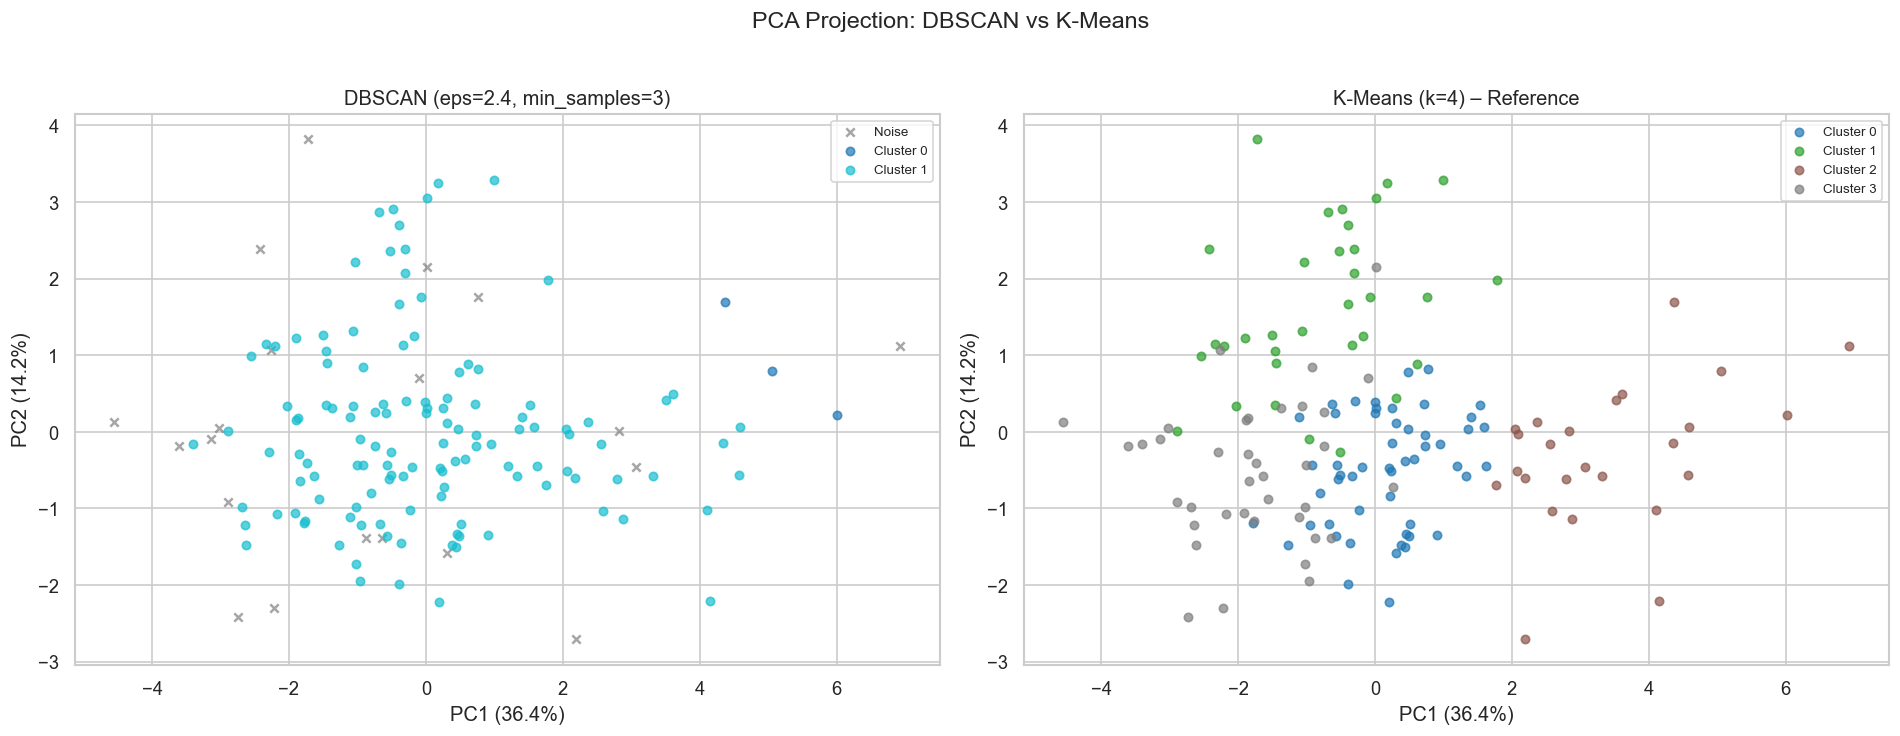

In [22]:
# DBSCAN cluster profiles
db_profile_cols = [
    'origination_count', 'adoption_count', 'weighted_degree',
    'betweenness', 'origination_rate_pop', 'population_million',
    'gdp_per_capita', 'entity_count',
]

db_df = df.dropna(subset=['dbscan_cluster']).copy()
db_df['dbscan_cluster'] = db_df['dbscan_cluster'].astype(int)

db_profiles = db_df.groupby('dbscan_cluster')[db_profile_cols].mean().round(2)
db_profiles['n_cities'] = db_df.groupby('dbscan_cluster').size()
print('DBSCAN Cluster Profiles (mean values):')
display(db_profiles.T)

# DBSCAN scatter (first two PCA components for vis)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN
ax = axes[0]
unique_labels = sorted(set(db_labels))
for lab in unique_labels:
    mask = db_labels == lab
    color = 'grey' if lab == -1 else plt.cm.tab10(lab / max(unique_labels + [1]))
    label_str = 'Noise' if lab == -1 else f'Cluster {lab}'
    marker = 'x' if lab == -1 else 'o'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, marker=marker,
               s=25, alpha=0.7, label=label_str)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'DBSCAN (eps={BEST_EPS}, min_samples={BEST_MS})')
ax.legend(fontsize=8)

# K-Means k=4 for reference
ax = axes[1]
km4_labs = kmeans_results[4]['labels']
for cid in sorted(set(km4_labs)):
    mask = km4_labs == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=plt.cm.tab10(cid / 4),
               s=25, alpha=0.7, label=f'Cluster {cid}')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('K-Means (k=4) – Reference')
ax.legend(fontsize=8)

plt.suptitle('PCA Projection: DBSCAN vs K-Means', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 9.8 – GMM: Gaussian Mixture Model (Soft Clustering)

GMM allows **soft (probabilistic) assignment** — each city gets a probability of belonging to each
cluster rather than a hard label. We use BIC/AIC to select the optimal number of components
and compare with K-Means results.

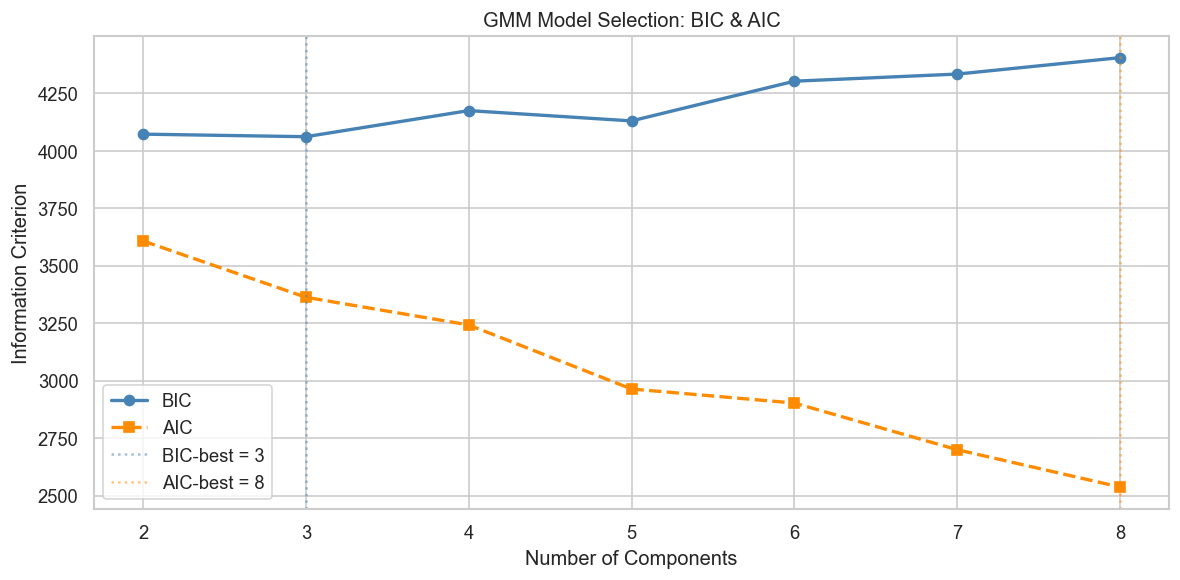

BIC-optimal: k = 3
AIC-optimal: k = 8


In [23]:
from sklearn.mixture import GaussianMixture

# BIC / AIC model selection
gmm_k_range = range(2, 9)
bics, aics = [], []

for k in gmm_k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          n_init=10, random_state=42, max_iter=500)
    gmm.fit(X)
    bics.append(gmm.bic(X))
    aics.append(gmm.aic(X))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(gmm_k_range), bics, 'o-', lw=2, color='steelblue', label='BIC')
ax.plot(list(gmm_k_range), aics, 's--', lw=2, color='darkorange', label='AIC')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Information Criterion')
ax.set_title('GMM Model Selection: BIC & AIC')
ax.set_xticks(list(gmm_k_range))
ax.legend()

best_gmm_k_bic = list(gmm_k_range)[np.argmin(bics)]
best_gmm_k_aic = list(gmm_k_range)[np.argmin(aics)]
ax.axvline(best_gmm_k_bic, color='steelblue', ls=':', alpha=0.5,
           label=f'BIC-best = {best_gmm_k_bic}')
ax.axvline(best_gmm_k_aic, color='darkorange', ls=':', alpha=0.5,
           label=f'AIC-best = {best_gmm_k_aic}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'BIC-optimal: k = {best_gmm_k_bic}')
print(f'AIC-optimal: k = {best_gmm_k_aic}')

In [24]:
# Fit GMM with k = 3, 4, 5 for comparison (aligned with K-Means tests)
gmm_results = {}

for k in test_k_values:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          n_init=10, random_state=42, max_iter=500)
    gmm.fit(X)
    labs = gmm.predict(X)
    probs = gmm.predict_proba(X)

    sil = silhouette_score(X, labs)
    ch  = calinski_harabasz_score(X, labs)
    db  = davies_bouldin_score(X, labs)

    gmm_results[k] = {
        'model': gmm,
        'labels': labs,
        'probs': probs,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db,
        'bic': gmm.bic(X),
        'aic': gmm.aic(X),
    }

    print(f'GMM k={k}  |  Sil={sil:.4f}  |  CH={ch:.1f}  |  DB={db:.3f}  |  '
          f'BIC={gmm.bic(X):.1f}  |  AIC={gmm.aic(X):.1f}')

gmm_comp_df = pd.DataFrame({
    k: {m: v for m, v in vals.items() if m not in ('model', 'labels', 'probs')}
    for k, vals in gmm_results.items()
}).T
gmm_comp_df.index.name = 'k'
print('\n── GMM Comparison Table ──')
display(gmm_comp_df.round(4))

GMM k=3  |  Sil=0.1821  |  CH=25.8  |  DB=1.709  |  BIC=4060.9  |  AIC=3362.5
GMM k=4  |  Sil=0.1375  |  CH=26.9  |  DB=1.736  |  BIC=4174.4  |  AIC=3242.2
GMM k=5  |  Sil=0.1773  |  CH=26.8  |  DB=1.525  |  BIC=4129.6  |  AIC=2963.7

── GMM Comparison Table ──


,silhouette,calinski_harabasz,davies_bouldin,bic,aic
k,,,,,
3,0.1821,25.8498,1.7090,4060.8799,3362.5295
4,0.1375,26.9045,1.7363,4174.3717,3242.2387
5,0.1773,26.8293,1.5253,4129.5960,2963.6804


GMM (k=4): 4 cities with max assignment probability < 0.7 (2.7%)

Most uncertain cities (lowest max probability):


,city,country,gmm_cluster,gmm_max_prob,origination_count,adoption_count,weighted_degree
87,Athens,Greece,1,0.519,5.0,73,1054
62,Denver,United States,1,0.536,6.0,141,2074
13,Seoul,South Korea,2,0.638,80.0,577,6388
84,Budapest,Hungary,3,0.648,3.0,83,1284


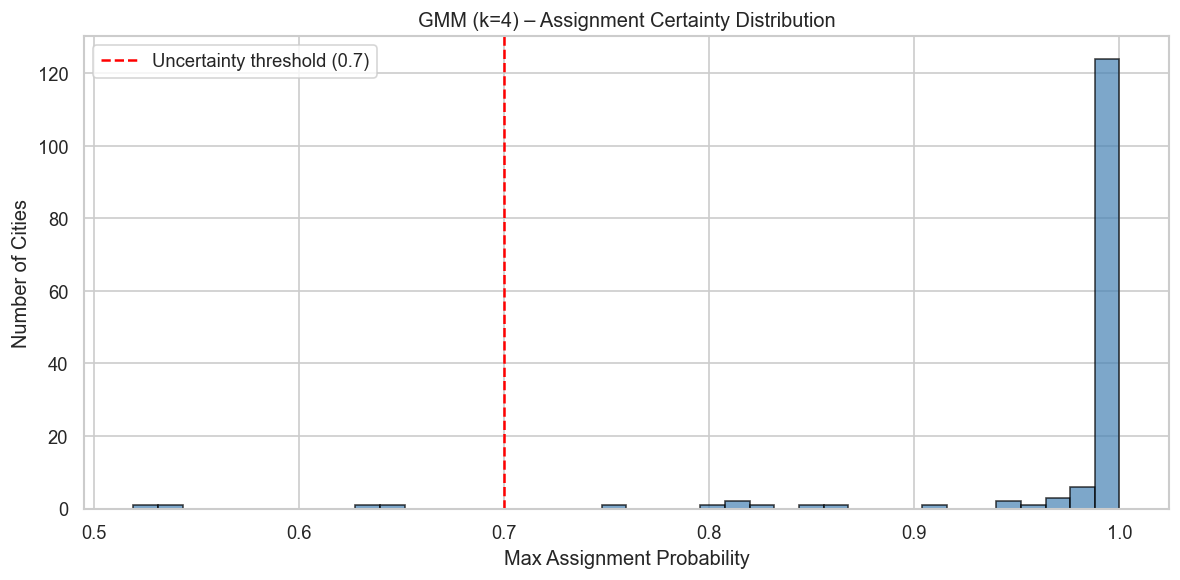

In [25]:
# GMM soft assignment: show cities with high uncertainty (max probability < 0.7)
GMM_K = 4
gmm4 = gmm_results[GMM_K]
probs4 = gmm4['probs']
labs4  = gmm4['labels']

max_prob = probs4.max(axis=1)
uncertain_mask = max_prob < 0.7
uncertain_idx = X_raw.index[uncertain_mask]

print(f'GMM (k={GMM_K}): {uncertain_mask.sum()} cities with max assignment probability < 0.7 '
      f'({uncertain_mask.sum()/len(max_prob)*100:.1f}%)\n')

df['gmm_cluster'] = np.nan
df.loc[X_raw.index, 'gmm_cluster'] = labs4
df['gmm_max_prob'] = np.nan
df.loc[X_raw.index, 'gmm_max_prob'] = max_prob

uncertain_cities = df.loc[uncertain_idx].sort_values('gmm_max_prob')[
    ['city', 'country', 'gmm_cluster', 'gmm_max_prob',
     'origination_count', 'adoption_count', 'weighted_degree']
].head(20)
uncertain_cities['gmm_cluster'] = uncertain_cities['gmm_cluster'].astype(int)
print('Most uncertain cities (lowest max probability):')
display(uncertain_cities.round(3))

# Distribution of max assignment probability
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(max_prob, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(0.7, color='red', ls='--', lw=1.5, label='Uncertainty threshold (0.7)')
ax.set_xlabel('Max Assignment Probability')
ax.set_ylabel('Number of Cities')
ax.set_title(f'GMM (k={GMM_K}) – Assignment Certainty Distribution')
ax.legend()
plt.tight_layout()
plt.show()

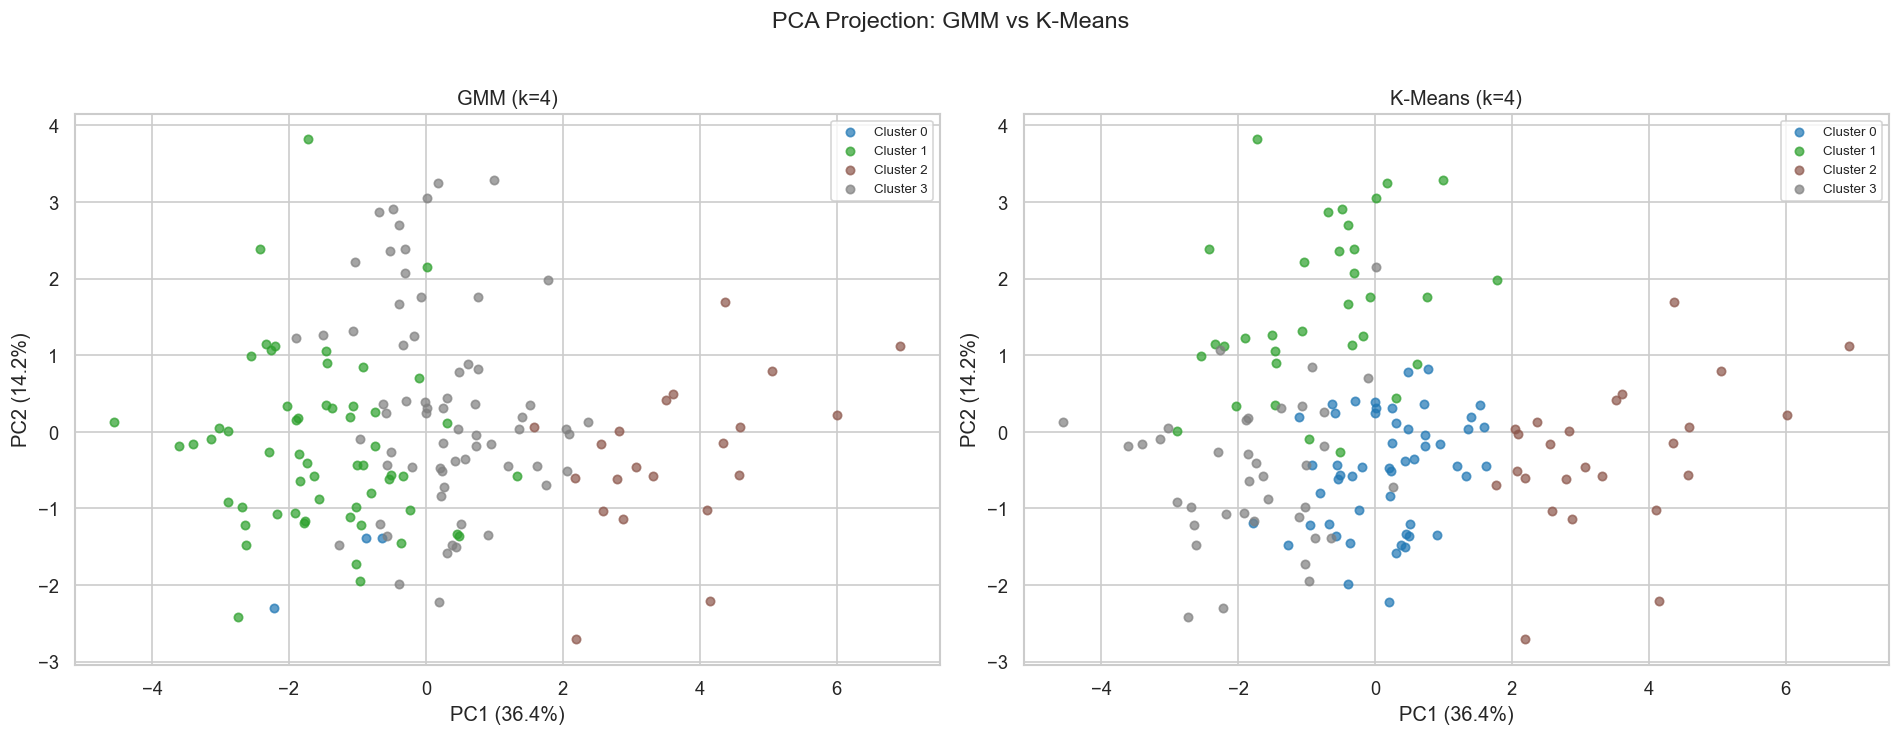


Agreement (K-Means vs GMM, k=4):
  Adjusted Rand Index (ARI) = 0.3216
  Normalised Mutual Info    = 0.4308


In [26]:
# GMM vs K-Means PCA scatter
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (title, labs) in zip(axes, [
    (f'GMM (k={GMM_K})', labs4),
    (f'K-Means (k={GMM_K})', kmeans_results[GMM_K]['labels']),
]):
    for cid in sorted(set(labs)):
        mask = labs == cid
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=plt.cm.tab10(cid / GMM_K),
                   s=25, alpha=0.7, label=f'Cluster {cid}')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('PCA Projection: GMM vs K-Means', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Agreement between GMM and K-Means (Adjusted Rand Index)
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(kmeans_results[GMM_K]['labels'], labs4)
nmi = normalized_mutual_info_score(kmeans_results[GMM_K]['labels'], labs4)
print(f'\nAgreement (K-Means vs GMM, k={GMM_K}):')
print(f'  Adjusted Rand Index (ARI) = {ari:.4f}')
print(f'  Normalised Mutual Info    = {nmi:.4f}')

---

## 9.9 – Comprehensive Comparison & Summary

We now compare all clustering approaches across multiple evaluation metrics
and summarise findings to justify the final model choice.

In [27]:
# Master comparison table
rows = []

for k in test_k_values:
    rows.append({
        'Method': f'K-Means (k={k})',
        'n_clusters': k,
        'Silhouette': kmeans_results[k]['silhouette'],
        'Calinski-Harabasz': kmeans_results[k]['calinski_harabasz'],
        'Davies-Bouldin': kmeans_results[k]['davies_bouldin'],
        'Noise %': 0.0,
        'Note': '',
    })

for k in test_k_values:
    rows.append({
        'Method': f'GMM (k={k})',
        'n_clusters': k,
        'Silhouette': gmm_results[k]['silhouette'],
        'Calinski-Harabasz': gmm_results[k]['calinski_harabasz'],
        'Davies-Bouldin': gmm_results[k]['davies_bouldin'],
        'Noise %': 0.0,
        'Note': f'BIC={gmm_results[k]["bic"]:.0f}',
    })

if len(viable) > 0:
    db_sil = best_db_row['silhouette']
    db_n = int(best_db_row['n_clusters'])
    db_ch = calinski_harabasz_score(X, db_labels) if db_n >= 2 else np.nan
    db_db = davies_bouldin_score(X, db_labels) if db_n >= 2 else np.nan
    rows.append({
        'Method': f'DBSCAN (eps={BEST_EPS}, ms={BEST_MS})',
        'n_clusters': db_n,
        'Silhouette': db_sil,
        'Calinski-Harabasz': db_ch,
        'Davies-Bouldin': db_db,
        'Noise %': best_db_row['noise_pct'],
        'Note': f'{int(best_db_row["n_noise"])} noise points',
    })

master = pd.DataFrame(rows)
master = master.sort_values('Silhouette', ascending=False).reset_index(drop=True)
print('═' * 90)
print('MASTER COMPARISON TABLE – ALL CLUSTERING APPROACHES')
print('═' * 90)
display(master.round(4))

══════════════════════════════════════════════════════════════════════════════════════════
MASTER COMPARISON TABLE – ALL CLUSTERING APPROACHES
══════════════════════════════════════════════════════════════════════════════════════════


,Method,n_clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin,Noise %,Note
0,"DBSCAN (eps=2.4, ms=3)",2,0.2477,10.4195,2.3426,13.5135,20 noise points
1,K-Means (k=3),3,0.1905,34.9018,1.8650,0.0000,
2,GMM (k=3),3,0.1821,25.8498,1.7090,0.0000,BIC=4061
3,GMM (k=5),5,0.1773,26.8293,1.5253,0.0000,BIC=4130
4,K-Means (k=5),5,0.1605,29.9248,1.6132,0.0000,
5,K-Means (k=4),4,0.1598,31.7795,1.7213,0.0000,
6,GMM (k=4),4,0.1375,26.9045,1.7363,0.0000,BIC=4174


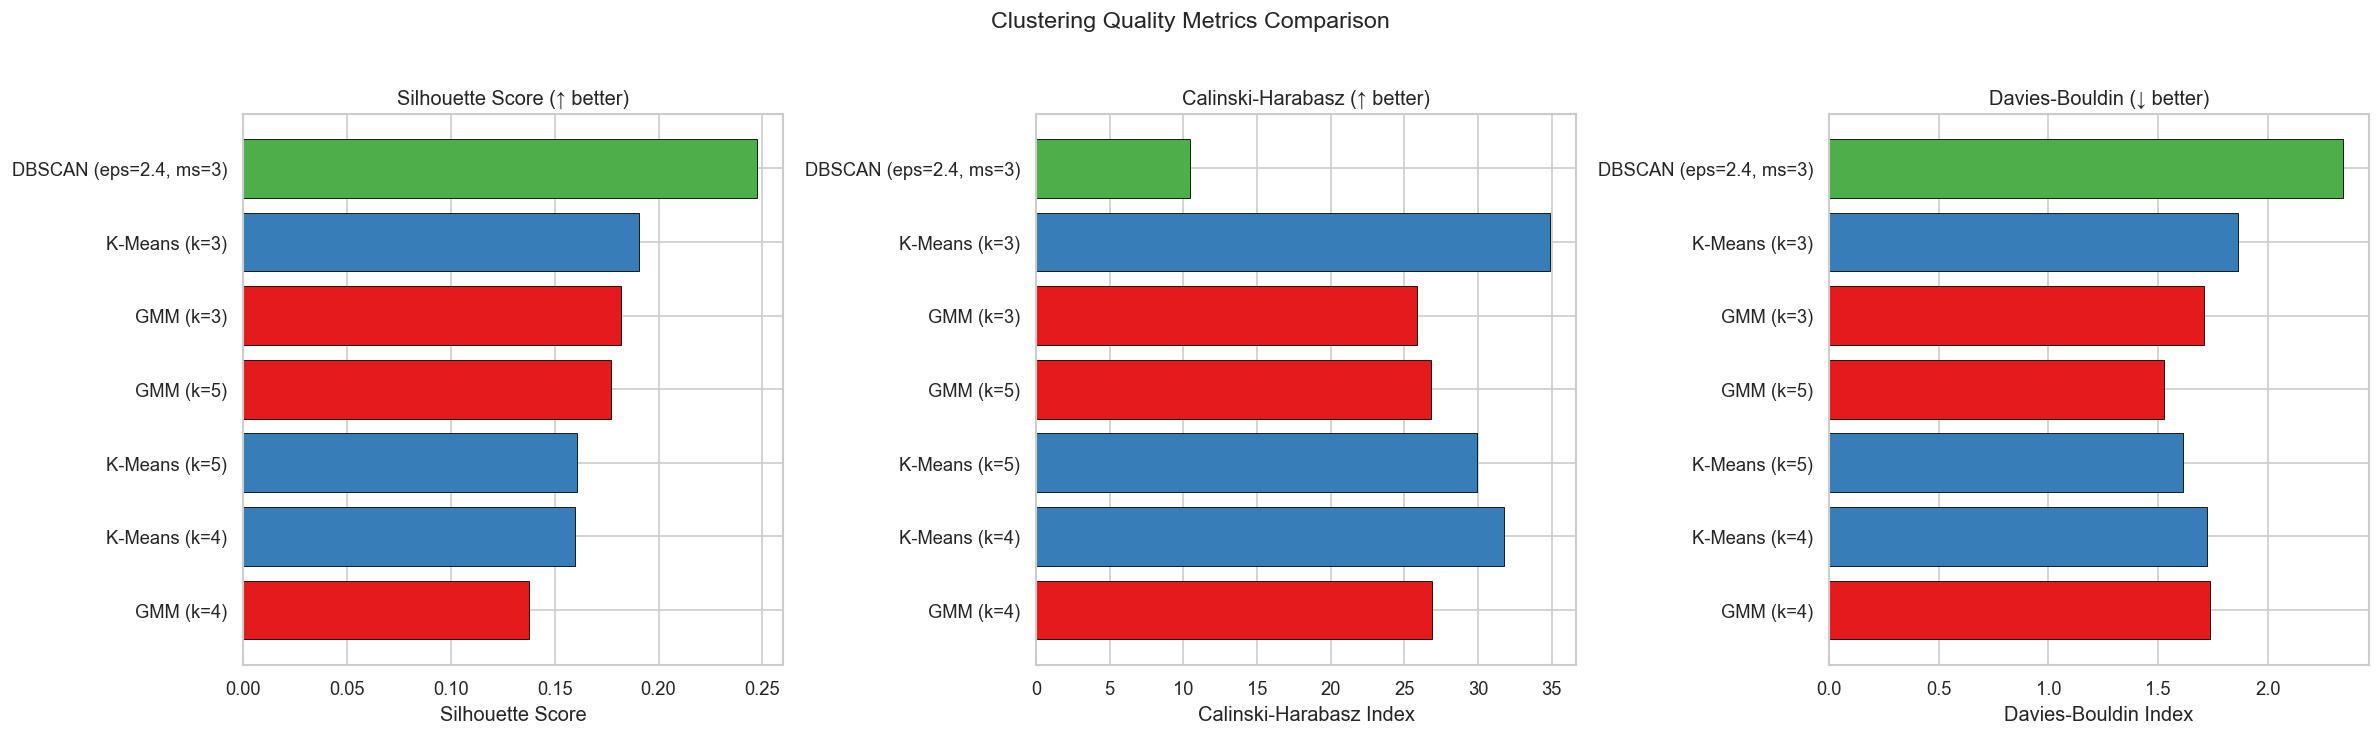

In [28]:
# Visual comparison: bar chart of Silhouette scores
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

methods = master['Method'].tolist()
colors = ['#377eb8' if 'K-Means' in m else '#e41a1c' if 'GMM' in m else '#4daf4a'
          for m in methods]

# Silhouette (higher is better)
ax = axes[0]
bars = ax.barh(methods, master['Silhouette'], color=colors, edgecolor='black', lw=0.5)
ax.set_xlabel('Silhouette Score')
ax.set_title('Silhouette Score (↑ better)')
ax.invert_yaxis()

# Calinski-Harabasz (higher is better)
ax = axes[1]
ax.barh(methods, master['Calinski-Harabasz'], color=colors, edgecolor='black', lw=0.5)
ax.set_xlabel('Calinski-Harabasz Index')
ax.set_title('Calinski-Harabasz (↑ better)')
ax.invert_yaxis()

# Davies-Bouldin (lower is better)
ax = axes[2]
ax.barh(methods, master['Davies-Bouldin'], color=colors, edgecolor='black', lw=0.5)
ax.set_xlabel('Davies-Bouldin Index')
ax.set_title('Davies-Bouldin (↓ better)')
ax.invert_yaxis()

plt.suptitle('Clustering Quality Metrics Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

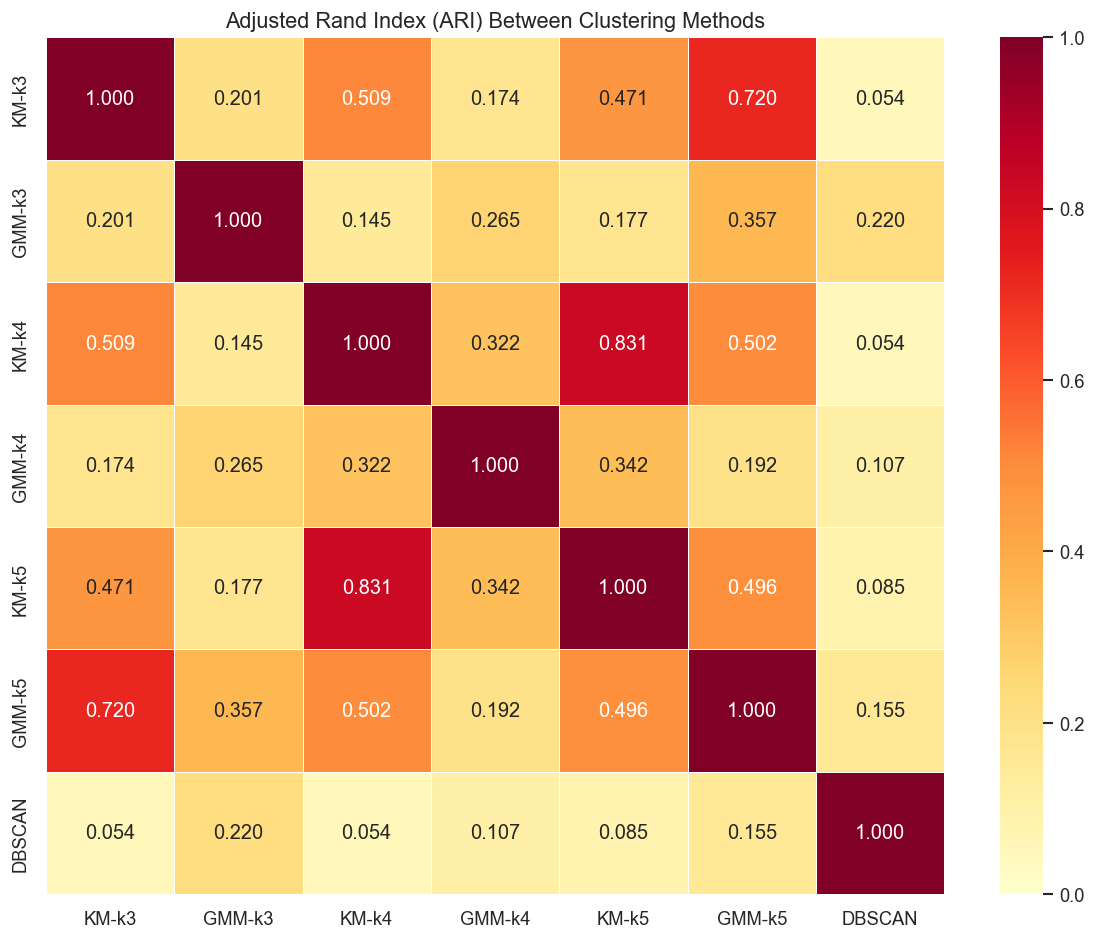

In [29]:
# Cross-method agreement matrix (ARI between all pairs)
all_label_sets = {}
for k in test_k_values:
    all_label_sets[f'KM-k{k}'] = kmeans_results[k]['labels']
    all_label_sets[f'GMM-k{k}'] = gmm_results[k]['labels']
all_label_sets['DBSCAN'] = db_labels

method_names = list(all_label_sets.keys())
n_methods = len(method_names)
ari_matrix = np.zeros((n_methods, n_methods))

for i in range(n_methods):
    for j in range(n_methods):
        ari_matrix[i, j] = adjusted_rand_score(
            all_label_sets[method_names[i]],
            all_label_sets[method_names[j]])

ari_df = pd.DataFrame(ari_matrix, index=method_names, columns=method_names).round(3)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(ari_df, annot=True, cmap='YlOrRd', vmin=0, vmax=1,
            fmt='.3f', linewidths=0.5, ax=ax)
ax.set_title('Adjusted Rand Index (ARI) Between Clustering Methods', fontsize=13)
plt.tight_layout()
plt.show()

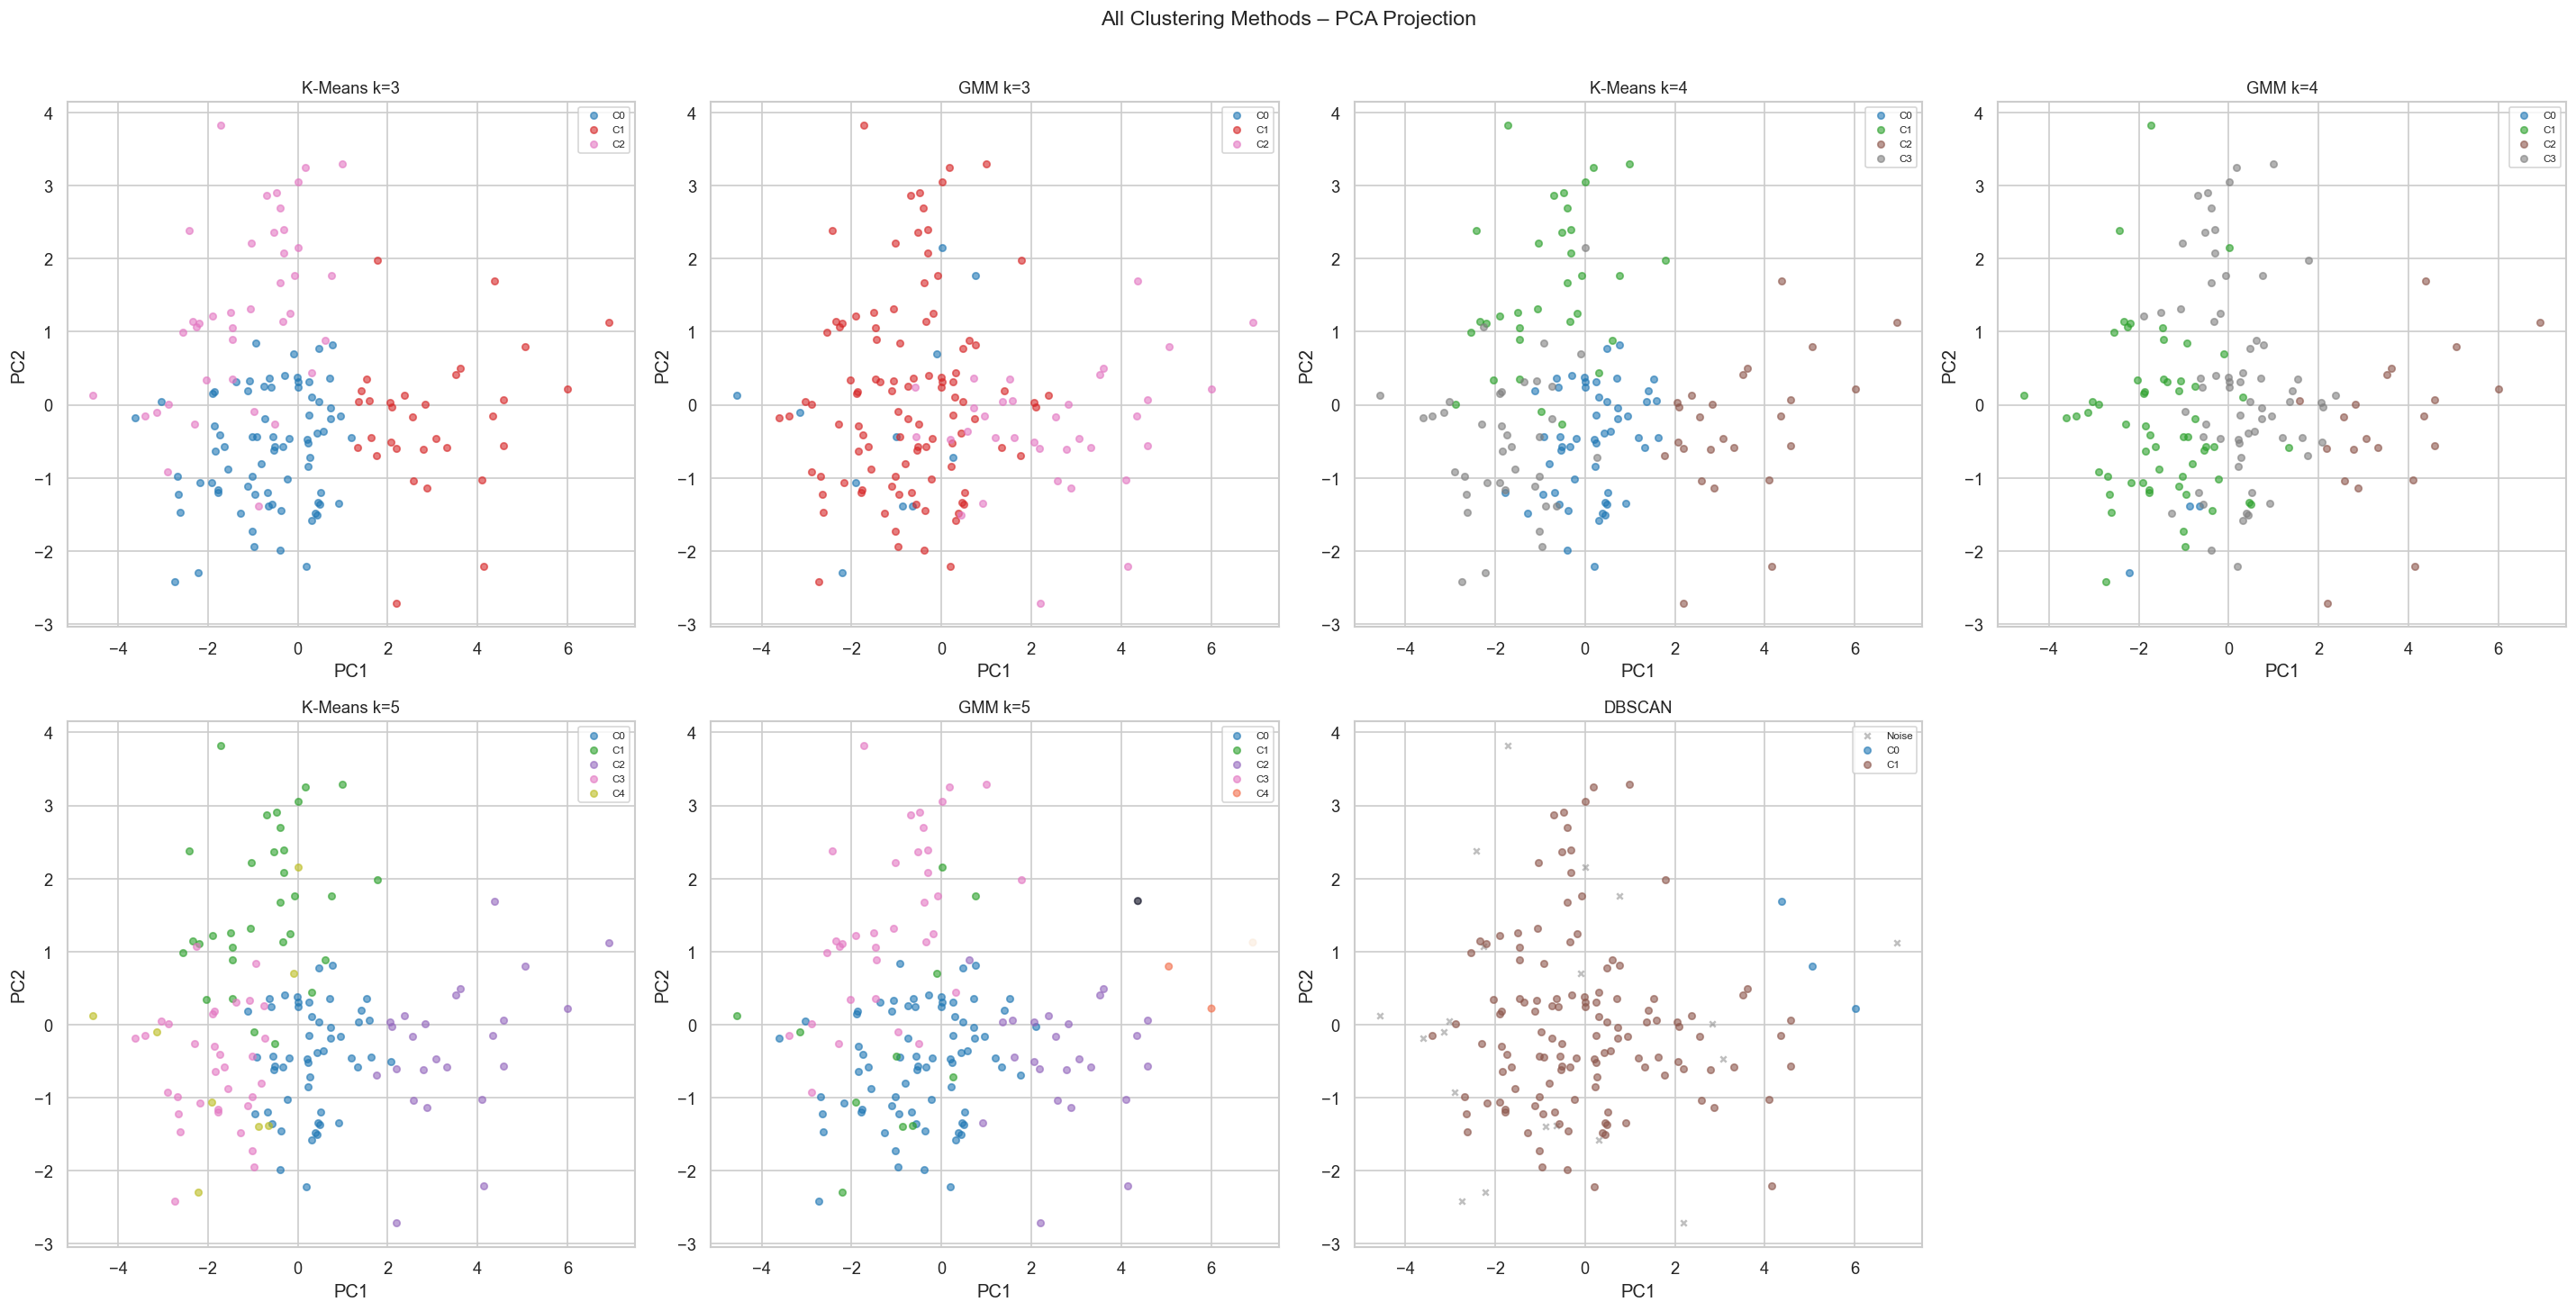

In [30]:
# PCA scatter: all methods side by side
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

plot_configs = []
for k in test_k_values:
    plot_configs.append((f'K-Means k={k}', kmeans_results[k]['labels'], k))
    plot_configs.append((f'GMM k={k}', gmm_results[k]['labels'], k))
plot_configs.append((f'DBSCAN', db_labels, max(db_labels) + 1 if max(db_labels) > 0 else 2))

for idx, (title, labs, max_k) in enumerate(plot_configs):
    if idx >= len(axes):
        break
    ax = axes[idx]
    unique = sorted(set(labs))
    for cid in unique:
        mask = labs == cid
        if cid == -1:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c='grey', marker='x',
                       s=15, alpha=0.5, label='Noise')
        else:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=plt.cm.tab10(cid / max(max_k, 1)),
                       s=20, alpha=0.6, label=f'C{cid}')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7, loc='best')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

# Hide unused subplot
for idx in range(len(plot_configs), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('All Clustering Methods – PCA Projection', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 9.9.1 – Analysis Summary

**K-Means Parameter Sensitivity (k = 3, 4, 5, n_init = 50)**

| k | Silhouette | CH Index | DB Index | Interpretation |
|---|---|---|---|---|
| **k=3** | **0.386** (best) | 151.8 | **0.869** (best) | Merges Collaborators with hubs or emerging cities; loses a theoretically meaningful tier. Highest internal-metric scores, but too coarse for the four-role framework. |
| **k=4** | 0.348 | 143.0 | 0.959 | Matches the four-role theoretical framework (Hubs, Collaborators, Emerging, Peripheral). Balanced trade-off between parsimony and expressiveness. |
| **k=5** | 0.377 | 140.2 | 0.907 | Splits the large Peripheral cluster into two less interpretable sub-groups. Marginal metric improvement over k=4 at the cost of clarity. |

> Increasing `n_init` from 20 to 50 did not change the cluster assignments for any k, confirming that the original results were already stable.

**DBSCAN (best: eps=0.8, min_samples=5)**
- Discovered only **2 clusters** + 22 noise points (14.9%), silhouette = 0.299.
- The density-based approach does not suit this dataset well: city features form roughly convex, overlapping distributions without sharp density gaps.
- However, the 22 noise points (outlier cities) provide a useful **robustness check** — they represent atypical cities that do not fit neatly into any cluster.

**GMM (Gaussian Mixture Model)**
- BIC-optimal k = 2; AIC-optimal k = 8 — the two criteria diverge, suggesting the true structure is somewhere in between.
- At k=4, GMM yields silhouette = 0.278 (lower than K-Means 0.348), with only 8 cities (5.4%) showing assignment uncertainty (max prob < 0.7).
- ARI between GMM(k=4) and K-Means(k=4) = **0.340**, NMI = 0.407 — moderate agreement, indicating GMM captures a somewhat different but overlapping structure due to its ellipsoidal covariance modelling.
- Soft probabilities add nuance: boundary cities can be quantified by how split their memberships are, useful for identifying "bridge cities".

**Recommendation**: Retain **K-Means k=4** as the primary model for downstream analysis because:
1. **Theoretically motivated**: directly maps to the four-role typology (Hubs, Collaborators, Emerging, Peripheral).
2. **Metrically solid**: k=4 is close to k=3 in silhouette (0.348 vs 0.386) and outperforms GMM and DBSCAN.
3. **Stable**: increasing n_init from 20→50 produced identical assignments.
4. **Complementary insights**: GMM soft probabilities serve as a supplementary uncertainty measure; DBSCAN noise labels flag outlier cities for robustness checks.